# S pombe ecDNA analysis

Modification of img-explorer to process _S pombe_ image data, using both nuclear and cell segmentation

In [1]:
# Import necessary packages

import os, glob, re, logging
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
from collections import defaultdict

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
import pandas as pd
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
# Define path names and data folders to process

# Define the location of the files to read
parent_directory = "/Users/nestor/Documents/NYU-ISG/microscope-data" # data directory
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory

experiment_list = ["01092026_Taka_pombe-live", "01162026_Taka_pombe-live", "01232026_Taka_pombe-live"]

In [3]:
# Do some housekeeping first

# Define the folder structure within each experiment
file_folders = {
    "image": "MIPs/MIPs_multichannel/", 
    "mask_n": "segmentation-masks/nuclei_masks/",
    "mask_c": "segmentation-masks/whole-cell_masks/"
}

# Load the function img_loadr() 
from load_files import img_loadr

def extract_base_name(filename):
    """
    Extract the base name from the file name without removing important parts of the name,
    such as the date and experiment information, while stripping the channel prefixes from masks.
    """
    name = os.path.basename(filename)

    # Only remove 'C1-', 'C2-', etc., from mask files
    if name.startswith(("C1-", "C2-", "C3-", "C4-", "C5-")):
        name = name[3:]  # Remove the first 3 characters (e.g., 'C1-', 'C2-', etc)
    
    # Remove the "_cp_masks" suffix for masks or ".ome" from image files if present
    name = name.replace("_cp_masks", "").replace(".ome", "")
    
    # Remove the file extension
    base_name = os.path.splitext(name)[0]
    
    return base_name

### Read files

The chunks below: 
1. read in multi-channel MIPs ("images"), nuclear masks, cell masks and spot coordinates
2. match images and mask file indexes to make sure they're paired correctly
3. display the overlay of image, cell masks and nuclear masks for one image

In [4]:
# CHUNK 1 # 
# Load maximum intensity projection (MIP) files
# and segmentation masks for images in all experiments listed

# Create a dictionary to store data across multiple experiments
all_experiments_data = {}

# Iterate through each experiment in experiment_list
for experiment in experiment_list:
    # Initialize data structures for the current experiment
    exp_data = {
        "all_images": {"image": [], "mask_n": [], "mask_c": []},
        "file_names": {"image": [], "mask_n": [], "mask_c": []},
        "base_names": {"image": [], "mask_n": [], "mask_c": []},
        "errors": []
    }

    # Read in the experimental groups reference file for each experiment
    exp_groups = pd.read_csv(os.path.join(parent_directory, experiment, "experimental-groups.csv"))

    # Process each file type using img_loadr
    with ThreadPoolExecutor(max_workers=4) as executor:
        for f in file_folders:
            file_path = os.path.join(parent_directory, experiment, file_folders[f])
            files = glob.glob(os.path.join(file_path, "*.tif"))
            results = executor.map(img_loadr, files)

            for result in results:
                image, filename = result
                if image is not None:
                    exp_data["all_images"][f].append(image)
                    exp_data["file_names"][f].append(filename)
                    exp_data["base_names"][f].append(extract_base_name(filename))
                else:
                    exp_data["errors"].append(f"Error loading {filename}")

    # Log the completion of processing for this experiment
    if exp_data["errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_data['errors'])} files.")
    else:
        logging.info(f"{experiment}: All images and masks processed successfully without errors.")
    
    # Store the experiment's data under its name
    all_experiments_data[experiment] = exp_data

# Optional: Summary of processed files for all experiments
for experiment, data in all_experiments_data.items():
    logging.info(f"{experiment}: Processed {len(data['file_names']['image'])} images, {len(data['file_names']['mask_n'])} nuclei masks and {len(data['file_names']['mask_c'])} cell masks.")
    
# Now for each experiment, all_images["image"] contains all the images (MIPs), 
# all_images["mask_n"] contains all the nuclei masks and 
# all_images["mask_c"] contains all the cell masks

2026-07-08 14:50:22,862 - INFO - 01092026_Taka_pombe-live: All images and masks processed successfully without errors.
2026-07-08 14:50:24,985 - INFO - 01162026_Taka_pombe-live: All images and masks processed successfully without errors.
2026-07-08 14:50:27,000 - INFO - 01232026_Taka_pombe-live: All images and masks processed successfully without errors.
2026-07-08 14:50:27,003 - INFO - 01092026_Taka_pombe-live: Processed 82 images, 82 nuclei masks and 82 cell masks.
2026-07-08 14:50:27,003 - INFO - 01162026_Taka_pombe-live: Processed 109 images, 109 nuclei masks and 109 cell masks.
2026-07-08 14:50:27,004 - INFO - 01232026_Taka_pombe-live: Processed 110 images, 110 nuclei masks and 110 cell masks.


In [5]:
# Optional: check dimensions of a given set of images, to verify they're correct

# Define function to check dimensions of images and masks
def img_sizr(image_types, file_indices, all_images):
    for f in file_indices:
        for image_type in image_types:
            try:
                image_shape = all_images[image_type][f].shape
                logging.info(f"File {f} ({image_type}): {image_shape}")
            except IndexError:
                logging.warning(f"File index {f} for {image_type} is out of range.")
            except KeyError:
                logging.error(f"Image type {image_type} does not exist.")

# Define the list of image types to check
image_types_to_check = ['image', 'mask_n', 'mask_c']  # Add 'mask_b' if you want to check background masks too

# And the list of file indices to check
test_files = [3, 4]

# Loop over each experiment in all_experiments_data
for experiment, data in all_experiments_data.items():
    logging.info(f"Running dimension check for experiment: {experiment}")
    img_sizr(image_types_to_check, test_files, data["all_images"])

2026-07-08 14:50:32,858 - INFO - Running dimension check for experiment: 01092026_Taka_pombe-live
2026-07-08 14:50:32,862 - INFO - File 3 (image): (3, 2048, 2048)
2026-07-08 14:50:32,863 - INFO - File 3 (mask_n): (2048, 2048)
2026-07-08 14:50:32,863 - INFO - File 3 (mask_c): (2048, 2048)
2026-07-08 14:50:32,864 - INFO - File 4 (image): (3, 2048, 2048)
2026-07-08 14:50:32,865 - INFO - File 4 (mask_n): (2048, 2048)
2026-07-08 14:50:32,865 - INFO - File 4 (mask_c): (2048, 2048)
2026-07-08 14:50:32,866 - INFO - Running dimension check for experiment: 01162026_Taka_pombe-live
2026-07-08 14:50:32,867 - INFO - File 3 (image): (3, 2048, 2048)
2026-07-08 14:50:32,868 - INFO - File 3 (mask_n): (2048, 2048)
2026-07-08 14:50:32,869 - INFO - File 3 (mask_c): (2048, 2048)
2026-07-08 14:50:32,869 - INFO - File 4 (image): (3, 2048, 2048)
2026-07-08 14:50:32,870 - INFO - File 4 (mask_n): (2048, 2048)
2026-07-08 14:50:32,870 - INFO - File 4 (mask_c): (2048, 2048)
2026-07-08 14:50:32,870 - INFO - Running

In [6]:
# CHUNK 2 # 
# Load spots data, if required

# Define some functions for loading
def load_spot_files(parent_directory, experiment, spots_folder="spotiflow_results"):
    """
    Lazy-load spot CSVs for a single experiment.
    Returns a dict matching your previous structure.
    """
    exp_spots = {
        "spot_files": {"spots": []},
        "spot_file_names": {"spots": []},
        "spot_base_names": {"spots": []},
        "spot_channels": [],
        "spot_errors": []
    }

    spots_path = os.path.join(parent_directory, experiment, spots_folder)
    csv_files = sorted(glob.glob(os.path.join(spots_path, "*.csv")))
    if not csv_files:
        logging.info(f"{experiment}: no spot files found in {spots_path}")
        return exp_spots

    for file in csv_files:
        try:
            spots = pd.read_csv(file)  # adjust dtype/columns if needed
            file_name = os.path.basename(file)

            # Robust channel extraction: supports C1-, C02_, c10-, etc.
            m = re.match(r'^[Cc](\d+)[-_]', file_name)
            channel = int(m.group(1)) if m else None

            exp_spots["spot_files"]["spots"].append(spots)
            exp_spots["spot_file_names"]["spots"].append(file_name)
            exp_spots["spot_base_names"]["spots"].append(extract_base_name(file_name))
            exp_spots["spot_channels"].append(channel)

        except Exception as e:
            exp_spots["spot_errors"].append({"file": file, "error": str(e)})
            logging.error(f"Error reading {file} in {experiment}: {str(e)}")

    if exp_spots["spot_errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_spots['spot_errors'])} files.")
    else:
        logging.info(f"{experiment}: All spot files loaded successfully ({len(csv_files)}).")

    return exp_spots

def ensure_spots_loaded(all_experiments_data, parent_directory, experiment, **kwargs):
    """
    Load spots for one experiment only if not already loaded.
    Stores under all_experiments_data[experiment]['spots'].
    """
    exp_data = all_experiments_data[experiment]
    if "spots" not in exp_data:
        exp_data["spots"] = load_spot_files(parent_directory, experiment, **kwargs)
    return exp_data["spots"]

# Optional: convenience to get a legacy-style dict if some code still expects it
def spots_dict_view(all_experiments_data, experiment_list):
    return {
        exp: all_experiments_data[exp].get("spots", {
            "spot_files": {"spots": []},
            "spot_file_names": {"spots": []},
            "spot_base_names": {"spots": []},
            "spot_channels": [],
            "spot_errors": []
        })
        for exp in experiment_list
    }

In [7]:
# Load spots data
for exp in experiment_list:
    ensure_spots_loaded(all_experiments_data, parent_directory, exp, spots_folder = "spotiflow_results")

2026-07-08 14:50:38,492 - INFO - 01092026_Taka_pombe-live: All spot files loaded successfully (164).
2026-07-08 14:50:38,592 - INFO - 01162026_Taka_pombe-live: All spot files loaded successfully (218).
2026-07-08 14:50:38,686 - INFO - 01232026_Taka_pombe-live: All spot files loaded successfully (220).


In [ ]:
# Optional: if need all_experiments_spots for older code, generate by running:
all_experiments_spots = spots_dict_view(all_experiments_data, experiment_list)

In [8]:
# CHUNK 3 #
# Match image indices to mask indices, to make sure they're paired correctly
# as they may not have been read in the same order

# Loop over each experiment in all_experiments_data to match image and mask indices
for experiment, data in all_experiments_data.items():
    logging.info(f"Matching image indices to mask indices for experiment: {experiment}")

    # Access the base names for images and masks in this experiment
    image_base_names = data['base_names']['image']
    nuc_base_names   = data['base_names']['mask_n']   # nuclear masks
    cell_base_names  = data['base_names']['mask_c']   # cell masks

    # Fast lookup: base_name -> index
    img_name_to_idx  = {bn: i for i, bn in enumerate(image_base_names)}
    nuc_name_to_idx  = {bn: i for i, bn in enumerate(nuc_base_names)}
    cell_name_to_idx = {bn: i for i, bn in enumerate(cell_base_names)}

    matched_triples = []
    missing_nuc = 0
    missing_cell = 0
    
    # Match by iterating over images (primary driver)
    for img_idx, bn in enumerate(image_base_names):
        n_idx = nuc_name_to_idx.get(bn)
        c_idx = cell_name_to_idx.get(bn)

        if n_idx is None:
            missing_nuc += 1
            logging.warning(f"[{experiment}] No matching NUCLEAR mask for image base_name='{bn}'")

        if c_idx is None:
            missing_cell += 1
            logging.warning(f"[{experiment}] No matching CELL mask for image base_name='{bn}'")

        # Only keep fully matched triplets
        if (n_idx is not None) and (c_idx is not None):
            matched_triples.append((img_idx, n_idx, c_idx))

    # Masks that don't have a corresponding image (useful for sanity checks)
    nuc_without_image  = sorted(set(nuc_name_to_idx.keys())  - set(img_name_to_idx.keys()))
    cell_without_image = sorted(set(cell_name_to_idx.keys()) - set(img_name_to_idx.keys()))

    # Log summary
    logging.info(
        f"{experiment}: Matched {len(matched_triples)} (image, nuc, cell) triplets. "
        f"Missing nuclear for {missing_nuc} images; missing cell for {missing_cell} images."
    )
    if nuc_without_image:
        logging.info(f"[{experiment}] Nuclear masks with no image match: {len(nuc_without_image)}")
    if cell_without_image:
        logging.info(f"[{experiment}] Cell masks with no image match: {len(cell_without_image)}")

    # Store results for downstream analysis
    data["matched_indices"] = matched_triples
    data["unmatched"] = {
        "images_missing_nuclear": missing_nuc,
        "images_missing_cell": missing_cell,
        "nuc_masks_without_image": nuc_without_image,
        "cell_masks_without_image": cell_without_image,
    }

# Now, data["matched_indices"] contains (img_idx, nuc_mask_idx, cell_mask_idx) triplets per experiment

2026-07-08 14:50:46,073 - INFO - Matching image indices to mask indices for experiment: 01092026_Taka_pombe-live
2026-07-08 14:50:46,076 - INFO - 01092026_Taka_pombe-live: Matched 82 (image, nuc, cell) triplets. Missing nuclear for 0 images; missing cell for 0 images.
2026-07-08 14:50:46,077 - INFO - Matching image indices to mask indices for experiment: 01162026_Taka_pombe-live
2026-07-08 14:50:46,135 - INFO - 01162026_Taka_pombe-live: Matched 109 (image, nuc, cell) triplets. Missing nuclear for 0 images; missing cell for 0 images.
2026-07-08 14:50:46,135 - INFO - Matching image indices to mask indices for experiment: 01232026_Taka_pombe-live
2026-07-08 14:50:46,135 - INFO - 01232026_Taka_pombe-live: Matched 110 (image, nuc, cell) triplets. Missing nuclear for 0 images; missing cell for 0 images.


In [ ]:
# Overlay the corresponding masks on a channel (given as c) of a given image
# to visually inspect

# Specify the index of the image to check
# and the channel to plot — remember C-1 for ImageJ is channel 0 for Python!
e_index = 0
image_index = 10

# Replace with the desired index
c = 2 # remember the channel order in these images

# Access the specific experiment's data
experiment_key = experiment_list[e_index]
experiment_data = all_experiments_data[experiment_key]

# Find the corresponding mask index for the specified image
# and define the image and mask pair
matched_indices = experiment_data["matched_indices"]

try:
    img_idx, nuc_idx, cell_idx = next(trip for trip in matched_indices if trip[0] == image_index)
except StopIteration:
    raise ValueError(f"No matched masks found for image_index={image_index} in experiment '{experiment_key}'")

# Define image and both masks
my_image   = experiment_data['all_images']['image'][image_index]
image_file = experiment_data['file_names']['image'][image_index]
my_mask_n  = experiment_data['all_images']['mask_n'][nuc_idx]
my_mask_c  = experiment_data['all_images']['mask_c'][cell_idx]

# Select the channel to display
channel_image = my_image[c, ...]

# Sanity checks on shapes
if channel_image.shape != my_mask_n.shape or channel_image.shape != my_mask_c.shape:
    print("Warning: The image and one or more masks have different sizes. Please check your data.")
else:
    # Mask background (0) so only labeled regions are drawn
    cell_overlay = np.ma.masked_where(my_mask_c == 0, my_mask_c)
    nuc_overlay  = np.ma.masked_where(my_mask_n == 0, my_mask_n)

    plt.figure(figsize=(10, 10))
    plt.imshow(channel_image, cmap='gray')              # base image in grayscale
    plt.imshow(cell_overlay, cmap='jet', alpha=0.5)    # cell mask in jet
    plt.imshow(nuc_overlay,  cmap='gray', alpha=0.75)    # nuclear mask in grayscale on top
    plt.title(f'File: {image_file}  |  Channel: {c}')
    # plt.axis('off')
    plt.show()

### Match cells and nuclei

The next few cells:
1. match nuclei masks to cell masks so that each nucleus is assigned to a cell body. It does this based on pixel overlap. The cell ID (cell_ID) will be our reference, since one cell can have multiple nuclei. Values of cell_ID == 0 are considered background.
2. Nuclei with no matched cell (nuclear ID > 0 AND cell_ID == 0) and cells with no nucleus (cell_ID > 0 AND nuc_ID == 0) will be labelled as "unassigned" and "empty" and ultimately thrown out
3. Create a summary table of nuclei counts per cell and a plot to inspect the distribution of number of nuclei per cell

In [9]:
# Create a function that matches nuclear masks to cell masks using pixel overlap

from collections import defaultdict

def assign_nuclei_to_cells(
    nuc_mask: np.ndarray,
    cell_mask: np.ndarray,
    min_overlap_px: int = 0,
    min_overlap_frac: float | None = None
):
    """
    Assign each nucleus (nuc_ID) to the cell (cell_ID) it overlaps the most,
    enforcing a minimum overlap requirement.

    Parameters
    ----------
    nuc_mask : 2D ndarray of int
        Labeled nuclear mask (0 = background, 1..N = nuclei labels).
    cell_mask : 2D ndarray of int
        Labeled cell mask (0 = background, 1..M = cell labels).
    min_overlap_px : int, default=0
        Minimum number of overlapping pixels required to assign a nucleus to a cell.
    min_overlap_frac : float in (0,1], optional
        Minimum fraction of the nucleus area that must overlap a cell to assign.
        If provided alongside min_overlap_px, both conditions must be met.

    Returns
    -------
    dict:
        {
          "nuc_to_cell": {nuc_ID -> cell_ID_or_0},
          "cell_to_nucs": {cell_ID -> [nuc_ID, ...]},
          "unassigned_nuclei": [nuc_ID, ...],
          "empty_cells": [cell_ID, ...],
          "nuc_as_cellID_mask": 2D ndarray (each nucleus pixel = its assigned cell_ID, else 0),
          "n_nuclei": int,
          "n_cells": int,
        }
    """
    if nuc_mask.shape != cell_mask.shape:
        raise ValueError("nuc_mask and cell_mask must have same shape")

    nuc_labels = np.unique(nuc_mask)
    nuc_labels = nuc_labels[nuc_labels != 0]
    cell_labels = np.unique(cell_mask)
    cell_labels = cell_labels[cell_labels != 0]

    nuc_to_cell = {}
    cell_to_nucs = defaultdict(list)
    nuc_as_cellID_mask = np.zeros_like(nuc_mask, dtype=cell_mask.dtype)

    for n_id in nuc_labels:
        n_region = (nuc_mask == n_id)
        n_area = int(n_region.sum())
        overlapped_cells = cell_mask[n_region]
        overlapped_cells = overlapped_cells[overlapped_cells != 0]

        if overlapped_cells.size == 0:
            nuc_to_cell[n_id] = 0
            continue

        unique_cells, counts = np.unique(overlapped_cells, return_counts=True)
        best_idx = int(np.argmax(counts))
        best_cell = int(unique_cells[best_idx])
        best_overlap_px = int(counts[best_idx])

        # Apply minimum-overlap criteria
        passes_px = (best_overlap_px >= min_overlap_px)
        passes_frac = True
        if (min_overlap_frac is not None) and (min_overlap_frac > 0):
            # fraction relative to nucleus area
            passes_frac = (best_overlap_px >= min_overlap_frac * n_area)

        if passes_px and passes_frac:
            nuc_to_cell[n_id] = best_cell
            nuc_as_cellID_mask[n_region] = best_cell
        else:
            nuc_to_cell[n_id] = 0  # unassigned

    # Build reverse mapping and diagnostics
    for n_id, c_id in nuc_to_cell.items():
        if c_id != 0:
            cell_to_nucs[c_id].append(int(n_id))

    empty_cells = [int(c) for c in cell_labels if len(cell_to_nucs.get(int(c), [])) == 0]
    unassigned_nuclei = [int(n) for n, c in nuc_to_cell.items() if c == 0]

    return {
        "nuc_to_cell": nuc_to_cell,
        "cell_to_nucs": dict(cell_to_nucs),
        "unassigned_nuclei": unassigned_nuclei,
        "empty_cells": empty_cells,
        "nuc_as_cellID_mask": nuc_as_cellID_mask,
        "n_nuclei": int(len(nuc_labels)),
        "n_cells": int(len(cell_labels)),
    }

In [10]:
# CHUNK 4 # 
# Map each nucleus to its corresponding cell mask 

# Set your thresholds here
MIN_OVERLAP_PX = 10           # e.g., require ≥10 px overlap
MIN_OVERLAP_FRAC = 0.05       # e.g., require ≥5% of nucleus area to be inside a cell (set None to disable)

for experiment in experiment_list:
    exp_data = all_experiments_data[experiment]
    matched_triples = exp_data["matched_indices"]  # list of (img_idx, nuc_idx, cell_idx)

    exp_results = []  # one entry per matched triple

    total_nuclei = 0
    total_cells = 0
    total_unassigned_nuclei = 0
    total_empty_cells = 0

    for (img_idx, nuc_idx, cell_idx) in matched_triples:
        nuc_mask = exp_data["all_images"]["mask_n"][nuc_idx]
        cell_mask = exp_data["all_images"]["mask_c"][cell_idx]

        if nuc_mask.ndim != 2 or cell_mask.ndim != 2:
            raise ValueError(f"Masks must be 2D label images; got shapes {nuc_mask.shape} and {cell_mask.shape}")

        result = assign_nuclei_to_cells(
            nuc_mask,
            cell_mask,
            min_overlap_px=MIN_OVERLAP_PX,
            min_overlap_frac=MIN_OVERLAP_FRAC
        )

        exp_results.append({
            "image_index": img_idx,
            "nuc_index": nuc_idx,
            "cell_index": cell_idx,
            **result,
        })

        total_nuclei += result["n_nuclei"]
        total_cells += result["n_cells"]
        total_unassigned_nuclei += len(result["unassigned_nuclei"])
        total_empty_cells += len(result["empty_cells"])

    # Store per-experiment results
    exp_data["nuc_cell_assignments"] = exp_results

    # Single compact summary per experiment
    logging.info(
        f"[{experiment}] Summary: nuclei={total_nuclei}, cells={total_cells}, "
        f"unassigned_nuclei={total_unassigned_nuclei}, empty_cells={total_empty_cells} "
        f"(min_overlap_px={MIN_OVERLAP_PX}, min_overlap_frac={MIN_OVERLAP_FRAC})"
    )

2026-07-08 14:51:31,189 - INFO - [01092026_Taka_pombe-live] Summary: nuclei=14189, cells=8704, unassigned_nuclei=4124, empty_cells=773 (min_overlap_px=10, min_overlap_frac=0.05)
2026-07-08 14:52:08,695 - INFO - [01162026_Taka_pombe-live] Summary: nuclei=15101, cells=10207, unassigned_nuclei=3230, empty_cells=1133 (min_overlap_px=10, min_overlap_frac=0.05)
2026-07-08 14:52:38,679 - INFO - [01232026_Taka_pombe-live] Summary: nuclei=10971, cells=7844, unassigned_nuclei=1523, empty_cells=665 (min_overlap_px=10, min_overlap_frac=0.05)


In [11]:
# Write a function to turn the mapping into a data frame

def map_to_df(exp_results, experiment_name, exp_data):
    """
    Convert nucleus→cell assignment results for one experiment into a tidy DataFrame.
    Includes base_name for each image.
    
    exp_results = list of dicts (from exp_data["nuc_cell_assignments"])
    experiment_name = str
    exp_data = the experiment_data dict (to look up base_names)
    """
    rows = []
    for res in exp_results:
        img_idx = res["image_index"]
        base_name = exp_data["base_names"]["image"][img_idx]  # <-- lookup base_name

        nuc_to_cell = res["nuc_to_cell"]
        for nuc_id, cell_id in nuc_to_cell.items():
            rows.append({
                "experiment": experiment_name,
                "image_index": img_idx,
                "base_name": base_name, 
                "nuc_ID": int(nuc_id),
                "cell_ID": int(cell_id) if cell_id != 0 else None,  # None = unassigned
                "assigned": (cell_id != 0),
            })
    return pd.DataFrame(rows)

In [12]:
# Convert nucleus -> cell mapping into a data frame

cellnuc_pairs = []

for experiment in experiment_list:
    exp_data = all_experiments_data[experiment]
    exp_results = exp_data["nuc_cell_assignments"]
    df_exp = map_to_df(exp_results, experiment, exp_data)
    cellnuc_pairs.append(df_exp)

cellnuc_pairs = pd.concat(cellnuc_pairs, ignore_index=True)

In [ ]:
# Inspect, if needed
print(cellnuc_pairs.head())

In [13]:
# Generate a data frame containing only true nucleus-cell pairs (those cells that contain a nucleus)
# (assigned + non-null cell_ID)

real_pairs_df = (
    cellnuc_pairs
      .loc[cellnuc_pairs["assigned"] & cellnuc_pairs["cell_ID"].notna(),
           ["experiment", "base_name", "image_index", "nuc_ID", "cell_ID", "assigned"]]
      .copy()
)

# Ensure integer dtypes for IDs
real_pairs_df["nuc_ID"]  = real_pairs_df["nuc_ID"].astype(int)
real_pairs_df["cell_ID"] = real_pairs_df["cell_ID"].astype(int)

# Optional: sort for easier inspection
real_pairs_df = real_pairs_df.sort_values(
    ["experiment", "base_name", "image_index", "cell_ID", "nuc_ID"]
).reset_index(drop=True)

In [102]:
# Inspect
print("real_pairs_df preview:")
print(real_pairs_df.head())

real_pairs_df preview:
                 experiment  \
0  01092026_Taka_pombe-live   
1  01092026_Taka_pombe-live   
2  01092026_Taka_pombe-live   
3  01092026_Taka_pombe-live   
4  01092026_Taka_pombe-live   

                                           base_name  image_index  nuc_ID  \
0  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2       2   
1  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2      13   
2  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2       5   
3  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2       4   
4  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2      12   

   cell_ID  assigned  
0        1      True  
1        1      True  
2        2      True  
3        3      True  
4        3      True  


In [14]:
# Now count the number of nucleus per cell, should we want to classify or select based on this

nuclei_counts = (
    real_pairs_df
      .groupby(["experiment", "base_name", "image_index", "cell_ID"], as_index=False)
      .agg(n_nuclei=("nuc_ID", "count"))
      .sort_values(["experiment", "base_name", "image_index", "cell_ID"])
      .reset_index(drop=True)
)

In [ ]:
# Inspect the data frame
print("\nnuclei_counts preview:")
print(nuclei_counts.head())

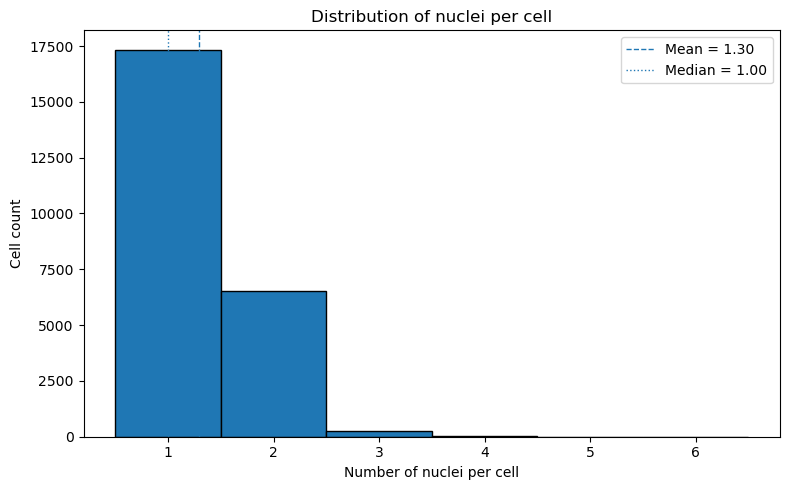

In [15]:
# Optional — plot a histogram showing the distribution of the number of nuclei in match_summary_df

# Ensure integer dtype
nuclei_counts["n_nuclei"] = nuclei_counts["n_nuclei"].astype(int)

if nuclei_counts.empty:
    print("nuclei_counts is empty; nothing to plot.")
else:
    vals = nuclei_counts["n_nuclei"].to_numpy()
    min_v, max_v = int(vals.min()), int(vals.max())
    # Integer-centered bins: [..., 0.5, 1.5, 2.5, ...]
    bins = np.arange(min_v - 0.5, max_v + 1.5, 1)

    plt.figure(figsize=(8, 5))
    plt.hist(vals, bins=bins, edgecolor="black")
    plt.xticks(range(min_v, max_v + 1))  # integer ticks
    plt.xlabel("Number of nuclei per cell")
    plt.ylabel("Cell count")
    plt.title("Distribution of nuclei per cell")

    # Mean & median reference lines
    mean_v = vals.mean()
    med_v = np.median(vals)
    plt.axvline(mean_v, linestyle="--", linewidth=1, label=f"Mean = {mean_v:.2f}")
    plt.axvline(med_v, linestyle=":",  linewidth=1, label=f"Median = {med_v:.2f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Spot assignment

The chunks below:
1. Create a few functions to assign spots to nuclei and cells based on their coordinates
2. Assign the spots found on each image to the nucleus or cytoplasm of each cell — it can expand the nuclear mask to account for spots found on the edges of the nucleus, which we found to be quite common and to affect the classification. No need to expand the cell masks, since there are few spots in the cytoplasm and they don't seem to accumulate on the periphery
3. Calculate a summary table of spots per cell (in nucleus vs cytoplasm)
4. Generate a plot showing number of spots in each compartment, in each experimental group

In [16]:
# CHUNK 5.1 #
# Define functions to assign spots to each cell and nucleus — i.e., annotate each spot with a cell_ID and nuc_ID
# Before assigning spots to nuclei, we will also dilate each nucleus by a factor of N pixels (0 by default)

from skimage.segmentation import expand_labels

# Define necessary functions

# This is a (perhaps a bit unnecessary) detector of the X and Y coordinates, 
# should they not be specified
def detect_xy_columns(df, prefer=("x","y")):
    candidates = [prefer, ("X","Y"), ("x_pix","y_pix"), ("x_px","y_px"), ("xp","yp"), ("x0","y0"), ("x1","y1")]
    cols = set(df.columns)
    for xk, yk in candidates:
        if xk in cols and yk in cols:
            return xk, yk
    # fallback: first two numeric columns
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) >= 2:
        return num_cols[0], num_cols[1]
    raise ValueError("Could not determine x/y columns in spots DataFrame")


# This is the function that will actually annotate the spots
def annotate_spots(
    spots_df,
    nuc_mask,
    cell_mask,
    x_col=None,
    y_col=None,
    require_nucleus: bool = False,
):
    """
    Return ONLY spots that fall inside a cell (cell_ID > 0).
    Adds just 'cell_ID' and 'nuc_ID' (nullable Int64). No extra flags.

    If require_nucleus=True, also require nuc_ID > 0. However, nuc_ID values == 0 could be either 
    in the cytoplasm (cell_ID > 0) or in the real background (cell_ID == 0)
    """
    out = spots_df.copy()
    if x_col is None or y_col is None:
        x_col, y_col = detect_xy_columns(out)
    out = out.loc[out[x_col].notna() & out[y_col].notna()].copy()

    if out.empty:
        return out.assign(
            cell_ID = pd.Series(dtype="Int64"),
            nuc_ID = pd.Series(dtype="Int64"),
        )

    xs = np.rint(out[x_col].to_numpy()).astype(int)
    ys = np.rint(out[y_col].to_numpy()).astype(int)

    h, w = cell_mask.shape
    xs = np.clip(xs, 0, w - 1)
    ys = np.clip(ys, 0, h - 1)

    cell_ids = cell_mask[ys, xs].astype(int)
    nuc_ids  = nuc_mask[ys, xs].astype(int)

    keep = (cell_ids > 0)
    if require_nucleus:
        keep &= (nuc_ids > 0)

    if not np.any(keep):
        # return empty with columns
        return out.iloc[0:0].assign(
            cell_ID=pd.Series(dtype="Int64"),
            nuc_ID=pd.Series(dtype="Int64"),
        )

    idx = out.index[keep]
    out = out.loc[keep].copy()
    out["cell_ID"] = pd.Series(cell_ids[keep], index=idx, dtype="Int64")
    out["nuc_ID"]  = pd.Series(nuc_ids[keep],  index=idx, dtype="Int64")
    return out

# Lastly, this function does the heavy lifting for multiple experiments
def annotate_spots_for_experiment(
    exp_data,
    channels=None, # If you want to annotate spots for a specific channel, set to [2] or [1, 2, 4], whatever may be the case
    x_col=None,
    y_col=None,
    require_nucleus: bool = False,
    include_spot_file: bool = False,      
    verify_filename_match: bool = True,
    nuc_expand_px: int = 0,  
):
    """
    For one experiment:
      - uses exp_data["matched_indices"] (list of (img_idx, nuc_idx, cell_idx))
      - finds spot CSVs matching each image's base_name (and optionally channel filter)
      - expands nuclear masks by 'nuc_expand_px' pixels before sampling
      - annotates each spot row with cell_ID / nuc_ID, except those in the background region (ROI == 0)
      - returns a tidy DataFrame (and stores it under exp_data['spots']['annotated_spots_df'])

    Parameters
    ----------
    exp_data : dict
        Your per-experiment dict in all_experiments_data[experiment]
        Must contain:
          - 'matched_indices': list of (img_idx, nuc_idx, cell_idx)
          - 'base_names'['image']: list of base names for images
          - 'all_images'['mask_n'], ['mask_c']: lists of 2D label arrays
          - 'spots': structure with lists 'spot_files'['spots'], 'spot_file_names'['spots'],
                     'spot_base_names'['spots'], 'spot_channels'
    channels : list[int] | None
        If provided, only annotate spots from these channels.
    x_col, y_col : str | None
        Coordinate columns. If None, will auto-detect via detect_xy_columns.

    Returns
    -------
    spots_annot_df : DataFrame
        Columns include original spot CSV columns + metadata:
        ['experiment','base_name','image_index','channel','spot_file','cell_ID','nuc_ID']
    """
    def index_spot_files(exp_data):
        base_names = exp_data["spots"]["spot_base_names"]["spots"]
        channels   = exp_data["spots"]["spot_channels"]
        idx_map = defaultdict(list)
        for i, (bn, ch) in enumerate(zip(base_names, channels)):
            idx_map[(bn, ch)].append(i)
        return idx_map
    
    if "spots" not in exp_data or not exp_data["spots"]["spot_files"]["spots"]:
        df = pd.DataFrame()
        exp_data.setdefault("spots", {})["annotated_spots_df"] = df
        return df

    matched_triples = exp_data["matched_indices"]            # (img_idx, nuc_idx, cell_idx)
    img_base_names  = exp_data["base_names"]["image"]
    idx_map         = index_spot_files(exp_data)

    frames = []
    for (img_idx, nuc_idx, cell_idx) in matched_triples:
        base_name = img_base_names[img_idx]
        nuc_mask  = exp_data["all_images"]["mask_n"][nuc_idx]
        cell_mask = exp_data["all_images"]["mask_c"][cell_idx]

        # Expand nuclear labels once per image, reuse for all spot files/channels
        nuc_mask_eff = expand_labels(nuc_mask, distance = nuc_expand_px) if nuc_expand_px and nuc_expand_px > 0 else nuc_mask

        available_ch = sorted({ch for (bn, ch) in idx_map if bn == base_name})
        to_do = [ch for ch in available_ch if (channels is None or ch in channels)]

        for ch in to_do:
            for spot_i in idx_map.get((base_name, ch), []):
                df_raw = exp_data["spots"]["spot_files"]["spots"][spot_i]
                fname  = exp_data["spots"]["spot_file_names"]["spots"][spot_i]
                spot_bn  = exp_data["spots"]["spot_base_names"]["spots"][spot_i]

                if verify_filename_match and (spot_bn != base_name):
                    # Shouldn't happen because of idx_map, but good to guard.
                    logging.warning(f"Base-name mismatch: image='{base_name}' vs spots='{spot_bn}' in file {fname}")
                    continue

                df_ann = annotate_spots(
                    df_raw, nuc_mask_eff, cell_mask, 
                    x_col = x_col, y_col = y_col, 
                    require_nucleus = require_nucleus
                )
                if df_ann.empty:
                    continue

                meta = dict(base_name=base_name, image_index=img_idx, channel=ch)
                if include_spot_file:
                    meta["spot_file"] = fname

                df_ann = df_ann.assign(**meta)
                for col in ("cell_ID","nuc_ID"):
                    if col in df_ann.columns:
                        df_ann[col] = df_ann[col].astype("Int64")
                frames.append(df_ann)

    df_valid = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    exp_data["spots"]["annotated_spots_df"] = df_valid
    return df_valid

In [48]:
# CHUNK 5.2 # 
# Do the actual spot annotation and generate the data frame
# Dilating the nuclei is optional, but will help correctly assign spots on the periphery of the nucleus
# Define dilation factor (in pixels) below

npx = 15

# I tested pixel values from 0 to 25 and saw an increase in nuclear spots 
# from ~20% with no dilation, to a plateau at ~30% after 10-15px
# Below there is code to count and plot the values if we want to re-test

# Create an empty dictionary to store results
all_spots_annot = []

for experiment in experiment_list:
    exp_data = all_experiments_data[experiment]
    # lazy-load spot CSVs if not already loaded
    ensure_spots_loaded(all_experiments_data, parent_directory, experiment, spots_folder = "spotiflow_results")

    # Keep only spots inside cells; allow in- or out-of-nucleus (set True to require nucleus too)
    df_valid = annotate_spots_for_experiment(
        exp_data,
        channels=[1, 2],
        x_col=None,
        y_col=None,
        nuc_expand_px=npx,
        require_nucleus=False  # <- set True if you want MUST be in a nucleus as well
    )
    if not df_valid.empty:
        all_spots_annot.append(df_valid.assign(experiment=experiment))

all_spots_annot = pd.concat(all_spots_annot, ignore_index=True) if all_spots_annot else pd.DataFrame()

In [ ]:
print("Annotated spots shape:", all_spots_annot.shape)
print(all_spots_annot.head(10))
print(all_spots_annot['channel'].unique())

In [18]:
# Sanity check to confirm there are no spots with <NA> as cell_ID or nuc_ID
assert not all_spots_annot["cell_ID"].isna().any(), "NA cell_ID found"
assert not all_spots_annot["nuc_ID"].isna().any(),  "NA nuc_ID found"
assert (all_spots_annot["cell_ID"] > 0).all()
# nuc_ID may be 0 (cyto) or >0 (nuclear)

In [49]:
# Reset the accumulator so a new run starts clean
#dilation_results = []

In [50]:
# Run a simple calculator to count the number of nuclear, cytoplasmic spots, and spots outside cells
# This will let us evaluate the changes caused by changing the nucleus dilation factor

# --- 0) set this to whatever you used in the last run ---
current_expand = npx  # e.g., 2, 5, 10

# --- 1) counts from the annotated, *inside-cell* spots ---
nuclear_n = int((all_spots_annot["nuc_ID"] > 0).sum())
cyto_n    = int((all_spots_annot["nuc_ID"] == 0).sum())

# --- 2) total spots across the same scope (all raw CSV rows for matched base_names/channels) ---
#     This gives us background = total - (nuclear + cyto)
total_spots = 0
channels_filter = None  # must match the 'channels=' argument you passed to the annotator

for exp in experiment_list:
    exp_data = all_experiments_data[exp]
    # make sure spots were loaded for every experiment used
    ensure_spots_loaded(all_experiments_data, parent_directory, exp, spots_folder="spotiflow_results")

    matched_triples = exp_data["matched_indices"]  # (img_idx, nuc_idx, cell_idx)
    img_base_names  = exp_data["base_names"]["image"]
    base_names_used = {img_base_names[img_idx] for (img_idx, _, _) in matched_triples}

    # iterate over spot files and sum rows for those base_names (respecting channel filter)
    spot_bns  = exp_data["spots"]["spot_base_names"]["spots"]
    spot_chs  = exp_data["spots"]["spot_channels"]
    spot_dfs  = exp_data["spots"]["spot_files"]["spots"]

    for i, (bn, ch) in enumerate(zip(spot_bns, spot_chs)):
        if (bn in base_names_used) and (channels_filter is None or ch in channels_filter):
            total_spots += len(spot_dfs[i])

background_n = int(total_spots - (nuclear_n + cyto_n))
if total_spots == 0:
    print("No spots found in this run; skipping summary.")
else:
    nuclear_frac   = nuclear_n   / total_spots
    cyto_frac      = cyto_n      / total_spots
    background_frac= background_n/ total_spots

    # --- 3) stash one row per category so you can append across runs ---
    # create the accumulator once (outside your runs) as: dilation_results = []
    try:
        dilation_results
    except NameError:
        dilation_results = []

    dilation_results += [
        {"nuc_expand_px": current_expand, "region": "nuclear",   "count": nuclear_n,   "fraction": nuclear_frac},
        {"nuc_expand_px": current_expand, "region": "cytoplasm", "count": cyto_n,      "fraction": cyto_frac},
        {"nuc_expand_px": current_expand, "region": "background","count": background_n,"fraction": background_frac},
    ]


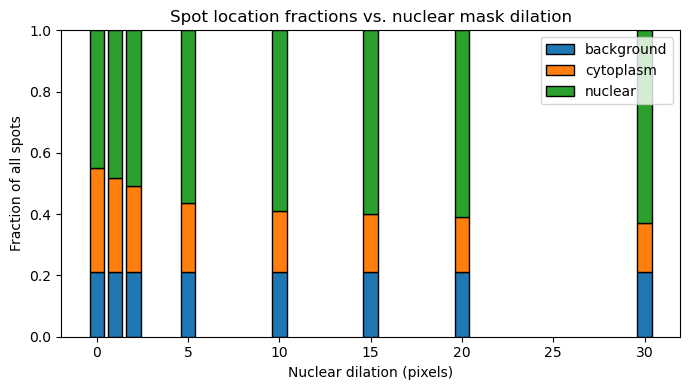

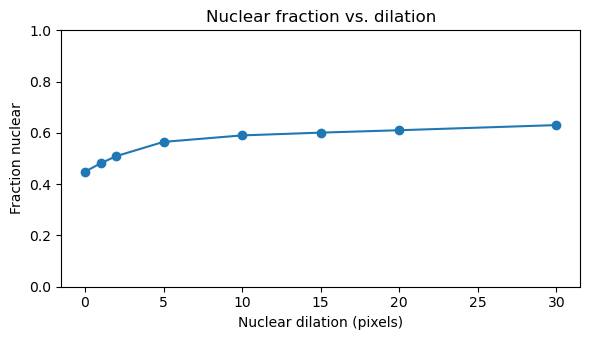

In [47]:
# And plot the results of the calculations above

dilation_df = pd.DataFrame(dilation_results)

# Create directory to save the plots to as PDFs
plots_dir = os.path.join(repo_directory, "plots")
os.makedirs(plots_dir, exist_ok=True)

# Ensure nice ordering
region_order = ["background", "cytoplasm", "nuclear"]
dilation_df["region"] = pd.Categorical(dilation_df["region"], categories=region_order, ordered=True)

# Pivot to wide for stacked bars
wide = (dilation_df
        .pivot(index="nuc_expand_px", columns="region", values="fraction")
        .fillna(0)
        .sort_index())

# --- Stacked bar (fractions sum to 1 per dilation) ---
fig, ax = plt.subplots(figsize=(7,4))
bottom = np.zeros(len(wide))
for r in region_order:
    ax.bar(wide.index, wide[r].to_numpy(), bottom=bottom, label=r, edgecolor="black")
    bottom += wide[r].to_numpy()
ax.set_xlabel("Nuclear dilation (pixels)")
ax.set_ylabel("Fraction of all spots")
ax.set_title("Spot location fractions vs. nuclear mask dilation")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(os.path.join(plots_dir, "dilation_fractions-plot.pdf"), format="pdf", bbox_inches="tight")
plt.show()

# --- Optional: line plot for nuclear fraction only (easy trend read) ---
fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(wide.index, wide["nuclear"], marker="o")
ax.set_xlabel("Nuclear dilation (pixels)")
ax.set_ylabel("Fraction nuclear")
ax.set_title("Nuclear fraction vs. dilation")
ax.set_ylim(0, 1.0)
plt.tight_layout()
fig.savefig(os.path.join(plots_dir, "dilation_nuclear_fraction-plot.pdf"), format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
# Overlay the spots over the corresponding cell + nuclear masks on a channel (given as c) of a given image
# to visually inspect

# Specify the index of the experiment and image to check
# and the channel to plot — remember C-1 for ImageJ is channel 0 for Python!
e_index = 0 # experiment index
image_index = 5 # image index
c = 0 # remember the channel order in these images
spot_channels_to_plot = [1]   # e.g., [2] to show only channel 2 spots; None = all channels
point_size = 15                # marker size for spots

# Access the specific experiment's data
experiment_key = experiment_list[e_index]
experiment_data = all_experiments_data[experiment_key]

spots_valid = experiment_data["spots"]["annotated_spots_df"]


# Find the corresponding mask index for the specified image
# and define the image and mask pair
matched_indices = experiment_data["matched_indices"]

try:
    img_idx, nuc_idx, cell_idx = next(trip for trip in matched_indices if trip[0] == image_index)
except StopIteration:
    raise ValueError(f"No matched masks found for image_index={image_index} in experiment '{experiment_key}'")

# Define image and both masks
my_image   = experiment_data['all_images']['image'][image_index]
image_file = experiment_data['file_names']['image'][image_index]
my_mask_n  = experiment_data['all_images']['mask_n'][nuc_idx]
my_mask_c  = experiment_data['all_images']['mask_c'][cell_idx]
channel_image = my_image[c, ...]

# Filter spots to this image (and optional channels)
if spots_valid is None or spots_valid.empty:
    spots_this = None
else:
    spots_this = spots_valid.loc[spots_valid["image_index"] == image_index]
    if spot_channels_to_plot is not None:
        spots_this = spots_this.loc[spots_this["channel"].isin(spot_channels_to_plot)]
    if spots_this.empty:
        spots_this = None

# Plot
if channel_image.shape != my_mask_n.shape or channel_image.shape != my_mask_c.shape:
    print("Warning: The image and one or more masks have different sizes. Please check your data.")
else:
    cell_overlay = np.ma.masked_where(my_mask_c == 0, my_mask_c)
    nuc_overlay  = np.ma.masked_where(my_mask_n == 0, my_mask_n)

    plt.figure(figsize=(10, 10))
    plt.imshow(channel_image, cmap='gray')             # base image
    plt.imshow(cell_overlay, cmap='jet', alpha=0.5)    # cell mask (jet)
    plt.imshow(nuc_overlay,  cmap='gray', alpha=0.75)  # nuclear mask (gray on top)

    # Scatter spots as yellow dots (if any)
    if spots_this is not None:
        # Try to use canonical x/y; fall back to auto-detect if needed
        x_col = "x" if "x" in spots_this.columns else None
        y_col = "y" if "y" in spots_this.columns else None
        if x_col is None or y_col is None:
            x_col, y_col = detect_xy_columns(spots_this)

        plt.scatter(
            spots_this[x_col],
            spots_this[y_col],
            s=point_size,
            c='yellow',
            marker='o',
            edgecolors='black',
            linewidths=0.3,
            alpha=0.9,
            label=f"Spots (n={len(spots_this)})"
        )
        plt.legend(loc="upper right")

    # Compose a helpful title
    if spots_this is not None and "channel" in spots_this.columns:
        ch_counts = spots_this["channel"].value_counts().sort_index()
        ch_txt = ", ".join([f"C{int(k)}={int(v)}" for k, v in ch_counts.items()])
        title_extra = f" | Spots: {ch_txt}"
    else:
        title_extra = " | Spots: none"

    plt.title(f'File: {image_file}  |  Image channel: {c}{title_extra}')
    # plt.axis('off')
    plt.tight_layout()
    plt.show()

In [51]:
# Read in experimental group data for all experiments
frames = []
groups_filename = "experimental-groups.csv"

for exp in experiment_list:
    path = os.path.join(parent_directory, exp, groups_filename)
    if not os.path.exists(path):
        logging.warning(f"{exp}: '{groups_filename}' not found at {path}")
        continue

    try:
        df = pd.read_csv(path)
    except Exception as e:
        logging.error(f"{exp}: failed reading {path}: {e}")
        continue

    # --- ensure required columns ---
    # filename (or base_name as fallback)
    if "filename" not in df.columns:
        if "base_name" in df.columns:
            df = df.rename(columns={"base_name": "filename"})
        else:
            logging.error(f"{exp}: missing 'filename' (and no 'base_name' to infer). Skipping.")
            continue

    # group
    if "group" not in df.columns:
        logging.error(f"{exp}: missing 'group'. Skipping.")
        continue

    # experiment -> prefer column 'experiment_folder' if present; else use folder name
    if "experiment_folder" in df.columns:
        df = df.rename(columns={"experiment_folder": "experiment"})
    if "experiment" not in df.columns:
        df["experiment"] = exp
    else:
        df["experiment"] = (
            df["experiment"].fillna(exp).astype(str).str.strip().replace({"": exp})
        )

    # clean filename
    df["filename"] = df["filename"].astype(str).str.strip()

    # rename filename -> base_name for consistency
    df = df.rename(columns={"filename": "base_name"})

    # --- STANDARDIZE base_name to match your other tables: ".ome.tif" -> "_MIP" ---
    # If it already ends with _MIP, leave as is; otherwise replace a *trailing* ".ome.tif" (case-insensitive).
    mask_already_mip = df["base_name"].str.endswith("_MIP", na=False)
    df.loc[~mask_already_mip, "base_name"] = (
        df.loc[~mask_already_mip, "base_name"]
          .str.replace(r"\.ome\.tif$", "_MIP", regex=True, flags=re.IGNORECASE)
    )

    # (Optional) log how many rows were converted this pass
    n_converted = (~mask_already_mip & df["base_name"].str.endswith("_MIP", na=False)).sum()
    if n_converted:
        logging.info(f"{exp}: standardized {n_converted} base_name(s) to '_MIP' suffix")

    frames.append(df)

# --- combine all experiments ---
if frames:
    exp_groups = pd.concat(frames, ignore_index=True, sort=True)
    # enforce key dtypes
    exp_groups["experiment"] = exp_groups["experiment"].astype(str)
    exp_groups["base_name"]  = exp_groups["base_name"].astype(str)
    # drop exact duplicates
    exp_groups = exp_groups.drop_duplicates()

    # optional: put key columns first
    key_cols = ["experiment", "base_name", "group"]
    other_cols = [c for c in exp_groups.columns if c not in key_cols]
    exp_groups = exp_groups[key_cols + other_cols]
else:
    logging.warning("No experimental-groups.csv files were loaded.")
    exp_groups = pd.DataFrame(columns=["experiment", "base_name", "group"])


2026-07-08 15:17:51,819 - INFO - 01092026_Taka_pombe-live: standardized 82 base_name(s) to '_MIP' suffix
2026-07-08 15:17:51,823 - INFO - 01162026_Taka_pombe-live: standardized 109 base_name(s) to '_MIP' suffix
2026-07-08 15:17:51,826 - INFO - 01232026_Taka_pombe-live: standardized 110 base_name(s) to '_MIP' suffix


In [52]:
# Incorporate experimental groups information into spot table
# by merging on experiment + base_name; keep only needed columns from exp_groups

all_spots_annot = all_spots_annot.merge(
    exp_groups,
    on = ["experiment", "base_name"],
    how = "left"
)

# Ensure intensity is numeric
all_spots_annot["intensity"] = pd.to_numeric(all_spots_annot["intensity"], errors = "coerce")

In [53]:
# CHUNK 6.1 # 
# Intensity analysis

# Perform background subtraction on the detected spots before plotting intensities to separate real from false spots

from skimage.measure import label  # 8-connected component labeling (use connectivity=2)

bg_rows = []

for experiment in experiment_list:
    # Run through the list of experiments and identify each of the images
    exp_data = all_experiments_data[experiment]
    matched_triples = exp_data["matched_indices"]              # (img_idx, nuc_idx, cell_idx)
    img_base_names  = exp_data["base_names"]["image"]

    # Avoid duplicates if the same image appears multiple times in matched_triples
    seen_images = set()

    for (img_idx, _nuc_idx, cell_idx) in matched_triples:
        if img_idx in seen_images:
            continue
        seen_images.add(img_idx)

        # Pull image (C,H,W) and its corresponding cell mask (H,W)
        img = exp_data["all_images"]["image"][img_idx]
        cell_mask = exp_data["all_images"]["mask_c"][cell_idx]
        base_name = img_base_names[img_idx]

        # Basic checks
        if img.ndim != 3:
            raise ValueError(f"{experiment}/{base_name}: expected image shape (C,H,W), got {img.shape}")
        if cell_mask.shape != img.shape[-2:]:
            raise ValueError(f"{experiment}/{base_name}: mask/image size mismatch: {cell_mask.shape} vs {img.shape[-2:]}")

        C, H, W = img.shape

        # ----- BACKGROUND SELECTION (largest 0-valued region in cell masks) -----
        
        bg_all = (cell_mask == 0)
        n_bg_all = int(bg_all.sum())
        if n_bg_all == 0:
            logging.warning(f"{experiment}/{base_name}: no background pixels (mask_c == 0). Metrics will be NaN.")
            # Create an all-False mask to keep logic simple below
            bg_mask = np.zeros_like(cell_mask, dtype=bool)
        else:
            # Label connected components in the background; 8-connectivity (connectivity=2)
            bg_labeled = label(bg_all.astype(np.uint8), connectivity=2, background=0)
            # Count pixels per component; index 0 counts the non-bg (False) so ignore it
            counts = np.bincount(bg_labeled.ravel())
            if counts.size <= 1:
                # Shouldn't happen if n_bg_all > 0, but guard anyway
                logging.warning(f"{experiment}/{base_name}: background labeling produced no components.")
                bg_mask = bg_all
            else:
                largest_label = int(np.argmax(counts[1:]) + 1)  # shift because we ignored 0
                bg_mask = (bg_labeled == largest_label)

        n_bg = int(bg_mask.sum())
        if n_bg == 0:
            logging.warning(f"{experiment}/{base_name}: largest background component has 0 pixels. Metrics will be NaN.")

        # ----- PER-CHANNEL STATS over the largest background component -----
        
        for c in range(C):  # channel index is 0-based
            vals = img[c][bg_mask]
            if vals.size == 0:
                bg_min = bg_median = bg_max = np.nan
            else:
                v = vals.astype(np.float64)
                bg_min    = float(np.min(v))
                bg_median = float(np.median(v))
                bg_max    = float(np.max(v))

            bg_rows.append({
                "experiment": experiment,
                "base_name": base_name,
                "image_index": img_idx,
                "channel": c + 1,               # 1-based channel index
                "bg_area": n_bg,        # pixels in the *largest* background region
                "bg_min": bg_min,
                "bg_median": bg_median,
                "bg_max": bg_max,
            })

# Long (tidy) format: one row per image × channel
bg_metrics_df = pd.DataFrame(bg_rows).sort_values(
    ["experiment", "base_name", "image_index", "channel"]
).reset_index(drop=True)

print("bg_metrics_df (long) preview:")
print(bg_metrics_df.head())

# Wide format: one row per image, columns per channel/stat (C1 = channel 0, etc.)
if not bg_metrics_df.empty:
    wide = (
        bg_metrics_df
        .pivot(index=["experiment","base_name","image_index"], columns="channel", values=["bg_min","bg_median","bg_max"])
        .sort_index()
    )
    # Flatten MultiIndex columns -> e.g., bg_median_C1, bg_median_C2, ...
    wide.columns = [f"{stat}_C{int(ch)}" for stat, ch in wide.columns]
    bg_metrics_wide = wide.reset_index()
else:
    bg_metrics_wide = pd.DataFrame(columns=["experiment","base_name","image_index"])

print("\nbg_metrics_wide (one row per image) preview:")
print(bg_metrics_wide.head())

bg_metrics_df (long) preview:
                 experiment  \
0  01092026_Taka_pombe-live   
1  01092026_Taka_pombe-live   
2  01092026_Taka_pombe-live   
3  01092026_Taka_pombe-live   
4  01092026_Taka_pombe-live   

                                           base_name  image_index  channel  \
0  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2        1   
1  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2        2   
2  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2        3   
3  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos1...           39        1   
4  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos1...           39        2   

   bg_area  bg_min  bg_median  bg_max  
0  2571126   154.0      205.0  1678.0  
1  2571126   118.0      145.0   216.0  
2  2571126   139.0      252.0  1646.0  
3  2745408   152.0      206.0  1567.0  
4  2745408   118.0      144.0   211.0  

bg_metrics_wide (one row per image) preview:
                 experiment 

In [54]:
# CHUNK 6.2 #
# Subtract the background minima from all spots

# I won't use the median, because in these images, the background region, as defined by the unmasked area of cells
# is likely to contain nuclei whose cell body was not segmented. 
# I could define the background as the region where both cell and nuclear masks take the value 0, but seems like overkill

# 1) Ensure join-key dtypes on spots
all_spots_annot["channel"] = all_spots_annot["channel"].astype(int)
all_spots_annot["image_index"] = all_spots_annot["image_index"].astype(int)

# 2) Merge and compute background-subtracted intensity
all_spots_annot = all_spots_annot.merge(
    bg_metrics_df,
    on = ["experiment", "base_name", "image_index", "channel"],
    how = "left",
    validate = "m:1",   # each spot should map to exactly one image×channel bg row
)

all_spots_annot["intensity"] = pd.to_numeric(all_spots_annot["intensity"], errors="coerce")
all_spots_annot["intensity_bs"] = all_spots_annot["intensity"] - all_spots_annot["bg_min"]

# (Optional) clip negatives to zero if you prefer
# all_spots_annot["intensity_bs"] = all_spots_annot["intensity_bs"].clip(lower=0)

# Quick sanity check
n_missing_bg = all_spots_annot["bg_min"].isna().sum()
if n_missing_bg:
    print(f"Warning: {n_missing_bg} spots have no background match. "
          "Check keys and channel indexing (spots are 1-based; bg_metrics_df was 0-based).")

In [56]:
print(all_spots_annot['channel'].unique())

[1 2]


Threshold (quantile=0.80) for channel 1 = 418.6
Threshold (quantile=0.20) for channel 2 = 199.6


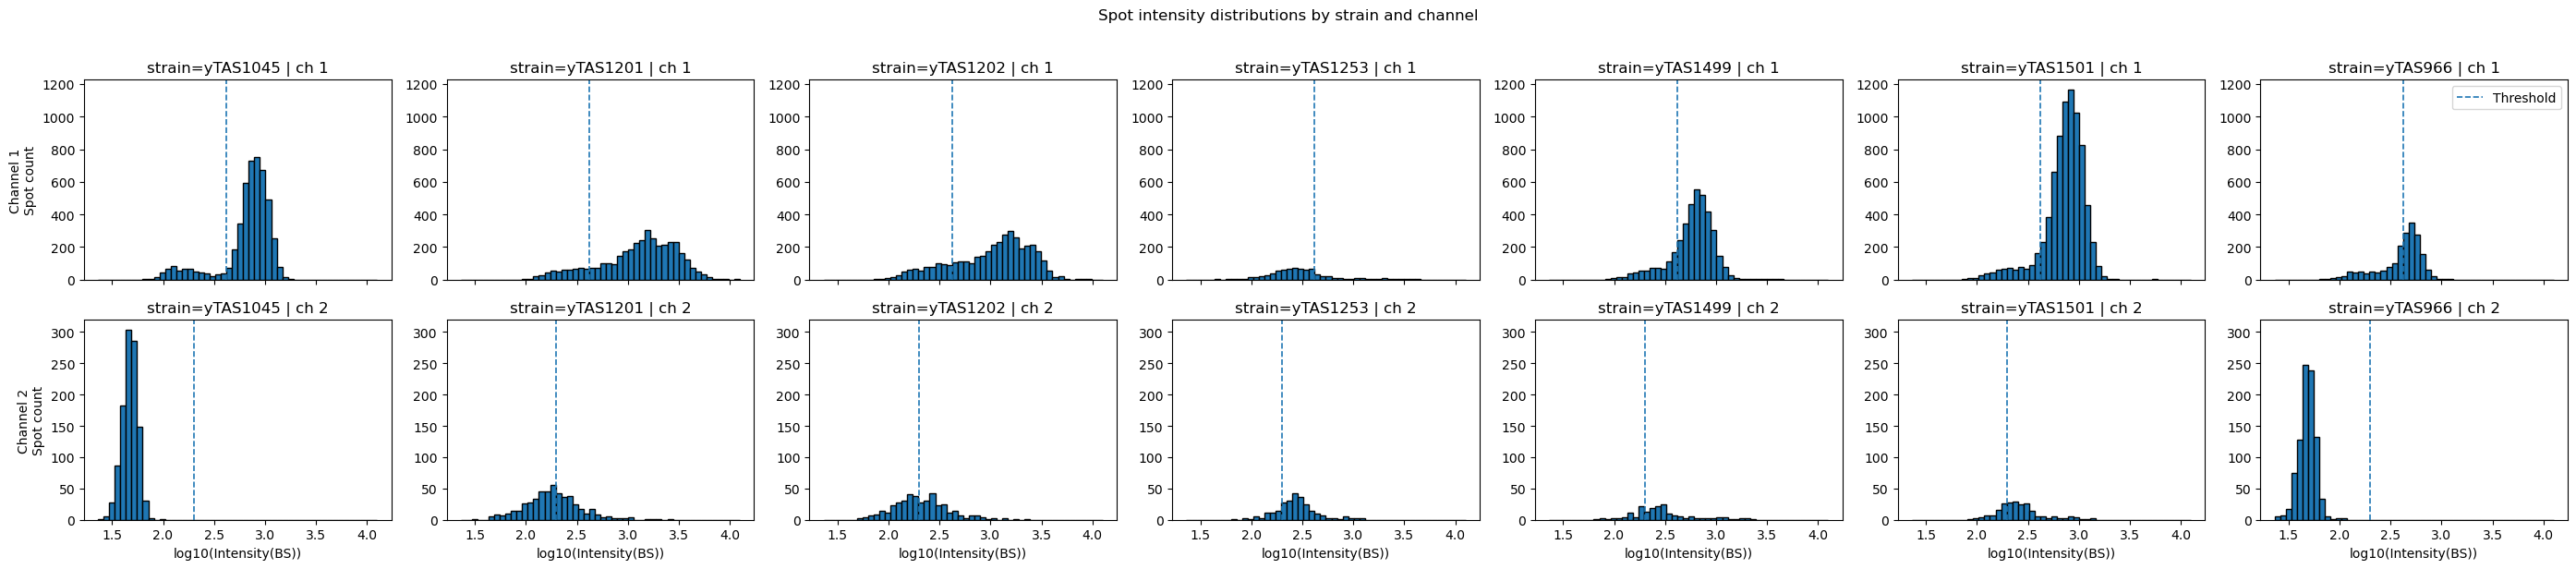

In [59]:
# Plot the spot intensity distribution for each of the experimental groups

# ---- CONFIG 
GROUP_VAR       = "strain"                  # <- set this to "group" or "strain" (or another column)
CONTROL_GROUP = "yTAS1253"                  # <- set this to the strain you want to use as control
THR_QUANTILE_CH1  = 0.80                    # Threshold for Channel 1 (GFP) e.g., 0.95, 0.99, etc. Values above will be kept
THR_QUANTILE_CH2 = 0.20                     # Threshold for Channel 2 (RFP). Values above will be kept as real foci
USE_ONLY_NUCLEAR_FOR_THR = False            # True to compute threshold from nuclear spots only
USE_LOG_SCALE_X = True                      # True if you want log10 intensity on the x-axis
NBINS = 50                                  # number of histogram bins
# ----------------

# --- 0. Basic checks ---
if GROUP_VAR not in all_spots_annot.columns:
    raise ValueError(f"Column '{GROUP_VAR}' not found in all_spots_annot.")
if "intensity_bs" not in all_spots_annot.columns:
    raise ValueError("Column 'intensity_bs' not found in all_spots_annot.")
if "channel" not in all_spots_annot.columns:
    raise ValueError("No 'channel' column found in all_spots_annot.")

# --- 1. Subset control group for threshold estimation (per-channel thresholds) ---
thr_subset = all_spots_annot.loc[all_spots_annot[GROUP_VAR] == CONTROL_GROUP].copy()

if USE_ONLY_NUCLEAR_FOR_THR and "spot_loc" in thr_subset.columns:
    thr_subset = thr_subset.loc[thr_subset["spot_loc"] == "nuclear"]

# We'll compute a separate threshold per channel
plot_df = all_spots_annot.loc[
    all_spots_annot["intensity_bs"].notna(),
    [GROUP_VAR, "channel", "intensity_bs"]
].copy()

channels = sorted(plot_df["channel"].dropna().unique())
groups   = sorted(plot_df[GROUP_VAR].dropna().unique())
if not groups:
    raise ValueError(f"No groups found to plot; check that '{GROUP_VAR}' merged correctly.")
if not channels:
    raise ValueError("No channels found to plot; check that 'channel' is correctly annotated.")

# --- 2. Threshold per channel from control group ---
# Map each channel to its quantile
thr_quantile_by_channel = {
    1: THR_QUANTILE_CH1,
    2: THR_QUANTILE_CH2,
}
DEFAULT_THR_QUANTILE = THR_QUANTILE_CH1   # fallback for any unlisted channel

thr_by_channel = {}

for ch in channels:
    thr_vals_ch = thr_subset.loc[
        thr_subset["channel"] == ch, "intensity_bs"
    ].dropna().to_numpy()

    # ... (your existing fallback logic stays exactly as-is) ...

    if thr_vals_ch.size == 0:
        print(f"Warning: no intensities at all for channel '{ch}'. Skipping threshold.")
        thr_by_channel[ch] = None
    else:
        q = thr_quantile_by_channel.get(ch, DEFAULT_THR_QUANTILE)  # <- only this line changes
        thr = np.quantile(thr_vals_ch, q)
        thr_by_channel[ch] = thr
        print(f"Threshold (quantile={q:.2f}) for channel {ch} = {thr:.4g}")
        
# --- 3. Prepare data for plotting (log10 optional) ---
if USE_LOG_SCALE_X:
    plot_df = plot_df.loc[plot_df["intensity_bs"] > 0].copy()  # only positive for log
    plot_df["intensity_plot"] = np.log10(plot_df["intensity_bs"])
    thr_plot_by_channel = {
        ch: (np.log10(t) if (t is not None and t > 0) else None)
        for ch, t in thr_by_channel.items()
    }
    xlab = "log10(Intensity(BS))"
else:
    plot_df["intensity_plot"] = plot_df["intensity_bs"]
    thr_plot_by_channel = thr_by_channel
    xlab = "Intensity"

# Shared bins across all groups and channels for fair comparison
vals = plot_df["intensity_plot"].to_numpy()
bins = np.linspace(vals.min(), vals.max(), NBINS + 1)

# --- 4. Set up subplot grid: rows = channels, columns = groups (from GROUP_VAR) ---
nrows = len(channels)
ncols = len(groups)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4 * ncols, 3 * nrows),
    sharex=True, sharey=False
)

# Ensure axes is always 2D for easy indexing
if nrows == 1 and ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes[np.newaxis, :]
elif ncols == 1:
    axes = axes[:, np.newaxis]

# Link y-axis within each row (channel) only, so groups are comparable
# per-channel, but each channel gets its own optimal scale
for i in range(nrows):
    for j in range(1, ncols):
        axes[i, j].sharey(axes[i, 0])


# --- 5. Plot histograms for each (channel, GROUP_VAR) ---
for i, ch in enumerate(channels):
    for j, g in enumerate(groups):
        ax = axes[i, j]
        mask = (plot_df["channel"] == ch) & (plot_df[GROUP_VAR] == g)
        x = plot_df.loc[mask, "intensity_plot"]

        if x.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        else:
            ax.hist(x, bins=bins, edgecolor="black")

        thr_plot = thr_plot_by_channel.get(ch, None)
        if thr_plot is not None:
            ax.axvline(thr_plot, linestyle="--", linewidth=1.2, label="Threshold")

        ax.set_title(f"{GROUP_VAR}={g} | ch {ch}")

        # Label axes nicely
        if i == nrows - 1:  # bottom row: x-axis label
            ax.set_xlabel(xlab)
        if j == 0:          # first column: y-axis label
            ax.set_ylabel(f"Channel {ch}\nSpot count")

        # Autoscale each row now that its y-axis is linked, so it fits that
        # channel's own data range (rather than inheriting the other channel's ylim)
        for j in range(ncols):
            axes[i, j].relim()
            axes[i, j].autoscale(axis="y")

# Put a single legend in the top-right subplot if thresholds exist
if any(t is not None for t in thr_plot_by_channel.values()):
    axes[0, -1].legend(loc="upper right")

fig.suptitle(f"Spot intensity distributions by {GROUP_VAR} and channel", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(plots_dir, "spot_filtering-plot.pdf"), format="pdf", bbox_inches="tight")
plt.show()

In [115]:
# CHUNK 6.3 #
# Subset the data frame to include only the spots above the thresholds set in the plot (THR_QUANTILE_CH1 and _CH2) for each channel 
# This quantiles correspond to the control group and the filtering will select only spots
# with intensities (post background subtraction) above the threshold's percentile of that of spots identified in the control group
#
# Channel 1 (GFP): threshold from control strain (no real GFP foci → all are artifacts).
# Channel 2 (RFP): threshold from same control strain (has histone RFP signal, so high-quantile
#                  cutoff separates noise peaks from genuine foci in other strains).

thr_ch1 = thr_by_channel.get(1, None)
thr_ch2 = thr_by_channel.get(2, None)

if thr_ch1 is None:
    raise ValueError("No threshold found for channel 1 in thr_by_channel.")
if thr_ch2 is None:
    raise ValueError("No threshold found for channel 2 in thr_by_channel.")

# Build a boolean mask — threshold applied per channel, all others passed through:
mask = all_spots_annot["intensity_bs"].notna() & (
    ((all_spots_annot["channel"] == 1) & (all_spots_annot["intensity_bs"] >= thr_ch1)) |
    ((all_spots_annot["channel"] == 2) & (all_spots_annot["intensity_bs"] >= thr_ch2)) |
    ((all_spots_annot["channel"] != 1) & (all_spots_annot["channel"] != 2))
)

# Apply mask
top_spots_annot = all_spots_annot.loc[mask].copy()

# Report
n_total     = len(all_spots_annot)
n_selected  = len(top_spots_annot)

n_filtered_ch1 = (all_spots_annot["channel"] == 1).sum() - (top_spots_annot["channel"] == 1).sum()
n_filtered_ch2 = (all_spots_annot["channel"] == 2).sum() - (top_spots_annot["channel"] == 2).sum()

print(
    f"Selected {n_selected} / {n_total} spots overall.\n"
    f"  Channel 1 (GFP): threshold ≥ {thr_ch1:.6g} → filtered out {n_filtered_ch1} spots.\n"
    f"  Channel 2 (RFP): threshold ≥ {thr_ch2:.6g} → filtered out {n_filtered_ch2} spots.\n"
    f"  Channel 3 (BF):  no threshold applied."
)

Selected 23047 / 30393 spots overall.
  Channel 1 (GFP): threshold ≥ 418.624 → filtered out 4694 spots.
  Channel 2 (RFP): threshold ≥ 199.6 → filtered out 2652 spots.
  Channel 3 (BF):  no threshold applied.


In [116]:
# CHUNK 7# 
# Classify filtered spots as nuclear or cytoplasmic based on their location within the cell

# Ensure nullable integer dtype is handled cleanly
if "nuc_ID" not in all_spots_annot.columns:
    raise KeyError("Expected column 'nuc_ID' not found in all_spots_annot")

top_spots_annot = top_spots_annot.assign(
    spot_loc = np.where(top_spots_annot["nuc_ID"].fillna(0).astype(int) > 0, "nuclear", "cyto")
)

# (Optional) use a categorical dtype to save memory / keep order
top_spots_annot["spot_loc"] = pd.Categorical(top_spots_annot["spot_loc"],
                                             categories = ["nuclear", "cyto"], ordered = True)

# Quick check (optional):
print(top_spots_annot["spot_loc"].value_counts())

spot_loc
nuclear    19892
cyto        3155
Name: count, dtype: int64


In [117]:
# Count nuclear and cytoplasmic spots for each cell-nucleus pair

# Keys for joining (adjust if you didn't include "experiment")
PAIR_KEYS = ["experiment", "base_name", "image_index", "cell_ID", "nuc_ID", "channel"]
CELL_KEYS = ["experiment", "base_name", "image_index", "cell_ID", "channel"]

# Make sure channel exists
if "channel" not in top_spots_annot.columns:
    raise ValueError("Expected a 'channel' column in top_spots_annot.")

channels = sorted(top_spots_annot["channel"].dropna().unique())

# 1) Count nuclear spots per cell–nucleus pair (nuc_ID > 0)
nuclear_counts = (
    top_spots_annot
      .loc[top_spots_annot["nuc_ID"].fillna(0).astype(int) > 0, PAIR_KEYS]
      .value_counts()
      .reset_index(name="n_spots_nuclear")
)

# 2) Count cytoplasmic spots per cell (nuc_ID == 0)
cyto_counts = (
    top_spots_annot
      .loc[top_spots_annot["nuc_ID"].fillna(0).astype(int) == 0, CELL_KEYS]
      .value_counts()
      .reset_index(name="n_spots_cyto")
)

# 3) Expand real_pairs_df across channels so each pair appears for every channel
channel_df = pd.DataFrame({"channel": channels})

# If you have pandas >= 1.2 you can use a cross join:
real_pairs_channel = real_pairs_df.merge(channel_df, how="cross")


# 4) Merge counts back, keeping zeros
spot_pair_summary = (
    real_pairs_channel
      .merge(nuclear_counts, on=PAIR_KEYS, how="left")
      .merge(cyto_counts,   on=CELL_KEYS,  how="left")
      .fillna({"n_spots_nuclear": 0, "n_spots_cyto": 0})
      .assign(
          n_spots_nuclear=lambda d: d["n_spots_nuclear"].astype(int),
          n_spots_cyto   =lambda d: d["n_spots_cyto"].astype(int),
          n_spots_total  =lambda d: d["n_spots_nuclear"] + d["n_spots_cyto"]
      )
)

# Optional: sort for inspection
spot_pair_summary = spot_pair_summary.sort_values(
    ["experiment", "base_name", "image_index", "cell_ID", "nuc_ID", "channel"]
).reset_index(drop=True)

# Incorporate experimental group info loaded earlier into spot_pair_summary
spot_pair_summary = pd.merge(spot_pair_summary, 
                            exp_groups,
                            on = ["experiment", "base_name"], how = 'left')

In [84]:
# Inspect
print(spot_pair_summary.head())
print(top_spots_annot.head())

                 experiment  \
0  01092026_Taka_pombe-live   
1  01092026_Taka_pombe-live   
2  01092026_Taka_pombe-live   
3  01092026_Taka_pombe-live   
4  01092026_Taka_pombe-live   

                                           base_name  image_index  nuc_ID  \
0  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2       2   
1  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2       2   
2  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2      13   
3  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2      13   
4  01092026_Taka_pombe_5X_yTAS1045_1_MMStack_Pos0...            2       5   

   cell_ID  assigned  channel  n_spots_nuclear  n_spots_cyto  n_spots_total  \
0        1      True        1                1             0              1   
1        1      True        2                0             0              0   
2        1      True        1                0             0              0   
3        1      True        2     

In [118]:
# Make a helper to generate a histogram of nuclear spots and cytoplasmic spots

def plot_int_hist_by_group(df, value_col, group_col = "group", group_row = None, title = None):
    """
    Plot histograms of integer-valued counts (e.g., n_spots_nuclear)
    for each experimental group, optionally separated by another variable (e.g., channel).

    Parameters
    ----------
    df : pandas.DataFrame
        Data frame containing group and value columns.
    value_col : str
        Column name containing integer values to plot (e.g., n_spots_nuclear).
    group_col : str, default="group"
        Column name defining experimental groups (plotted as columns).
    group_row : str or None, default=None
        Optional column defining row facets (e.g., 'channel').
        If None, all data are plotted in one row.
    title : str or None, default=None
        Overall figure title.
    """
    
    # Drop rows missing key columns and coerce counts to integer
    cols_needed = [value_col, group_col] + ([group_row] if group_row else [])
    d = df.loc[df[group_col].notna(), cols_needed].copy()
    d[value_col] = d[value_col].fillna(0).astype(int)

    groups = sorted(d[group_col].unique())
    if len(groups) == 0:
        print("No groups to plot.")
        return

    # Determine rows and columns
    if group_row is not None:
        row_groups = sorted(d[group_row].dropna().unique())
    else:
        row_groups = [None]

    nrows = len(row_groups)
    ncols = len(groups)

    min_v = int(d[value_col].min())
    max_v = int(d[value_col].max())
    bins = np.arange(min_v - 0.5, max_v + 1.5, 1)  # integer-centered bins

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4 * ncols, 3.5 * nrows),
        sharex=True, sharey=True
    )
    
    # Ensure 2D array for easy indexing
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes[np.newaxis, :]
    elif ncols == 1:
        axes = axes[:, np.newaxis]

    # Plot histograms
    for i, rg in enumerate(row_groups):
        d_row = d if rg is None else d.loc[d[group_row] == rg]
        for j, gc in enumerate(groups):
            ax = axes[i, j]
            subset = d_row.loc[d_row[group_col] == gc, value_col]

            if subset.empty:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                continue

            ax.hist(subset, bins=bins, edgecolor="black")
            ax.set_xlabel(value_col)
            ax.set_xticks(range(min_v, max_v + 1))
            ax.set_title(str(gc))

            if j == 0:
                label = "Count of cell–nucleus pairs"
                if group_row:
                    label += f"\n({group_row} = {rg})"
                ax.set_ylabel(label)

    if title is None:
        title = f"Distribution of {value_col} by {group_col}"
        if group_row:
            title += f" and {group_row}"

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

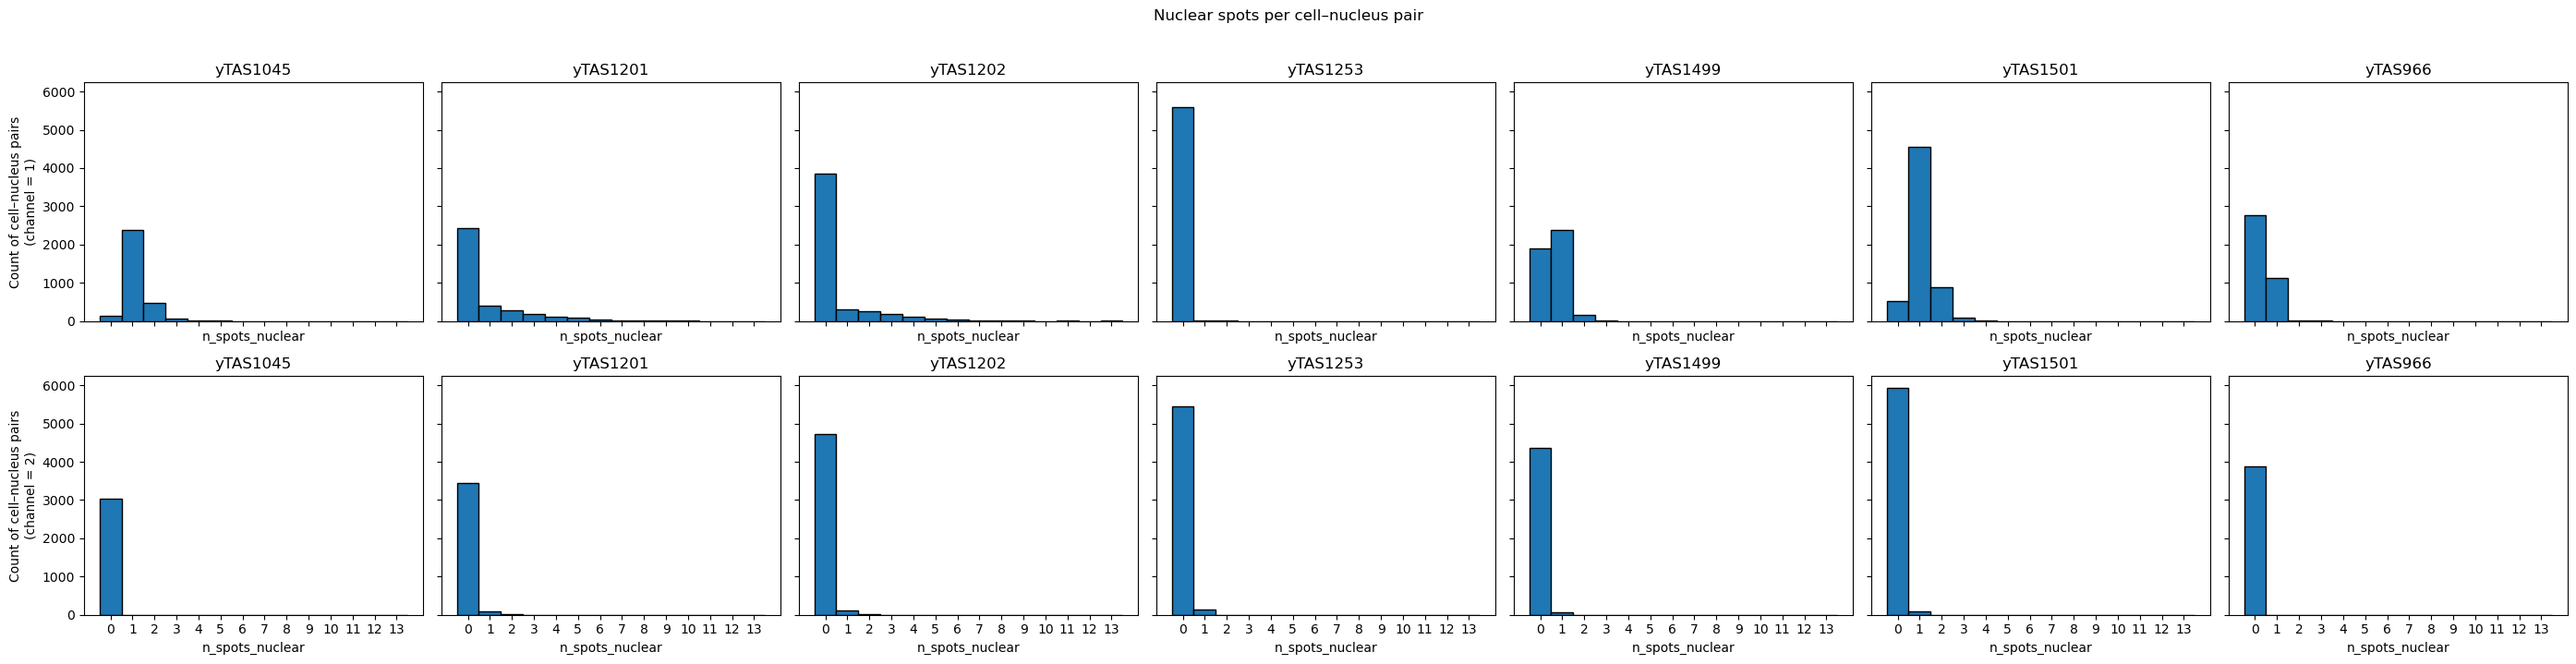

In [119]:
# 1) Plot nuclear spots per cell
plot_int_hist_by_group(spot_pair_summary, "n_spots_nuclear", 
                       group_col = "strain", group_row = "channel",
                       title = "Nuclear spots per cell–nucleus pair")

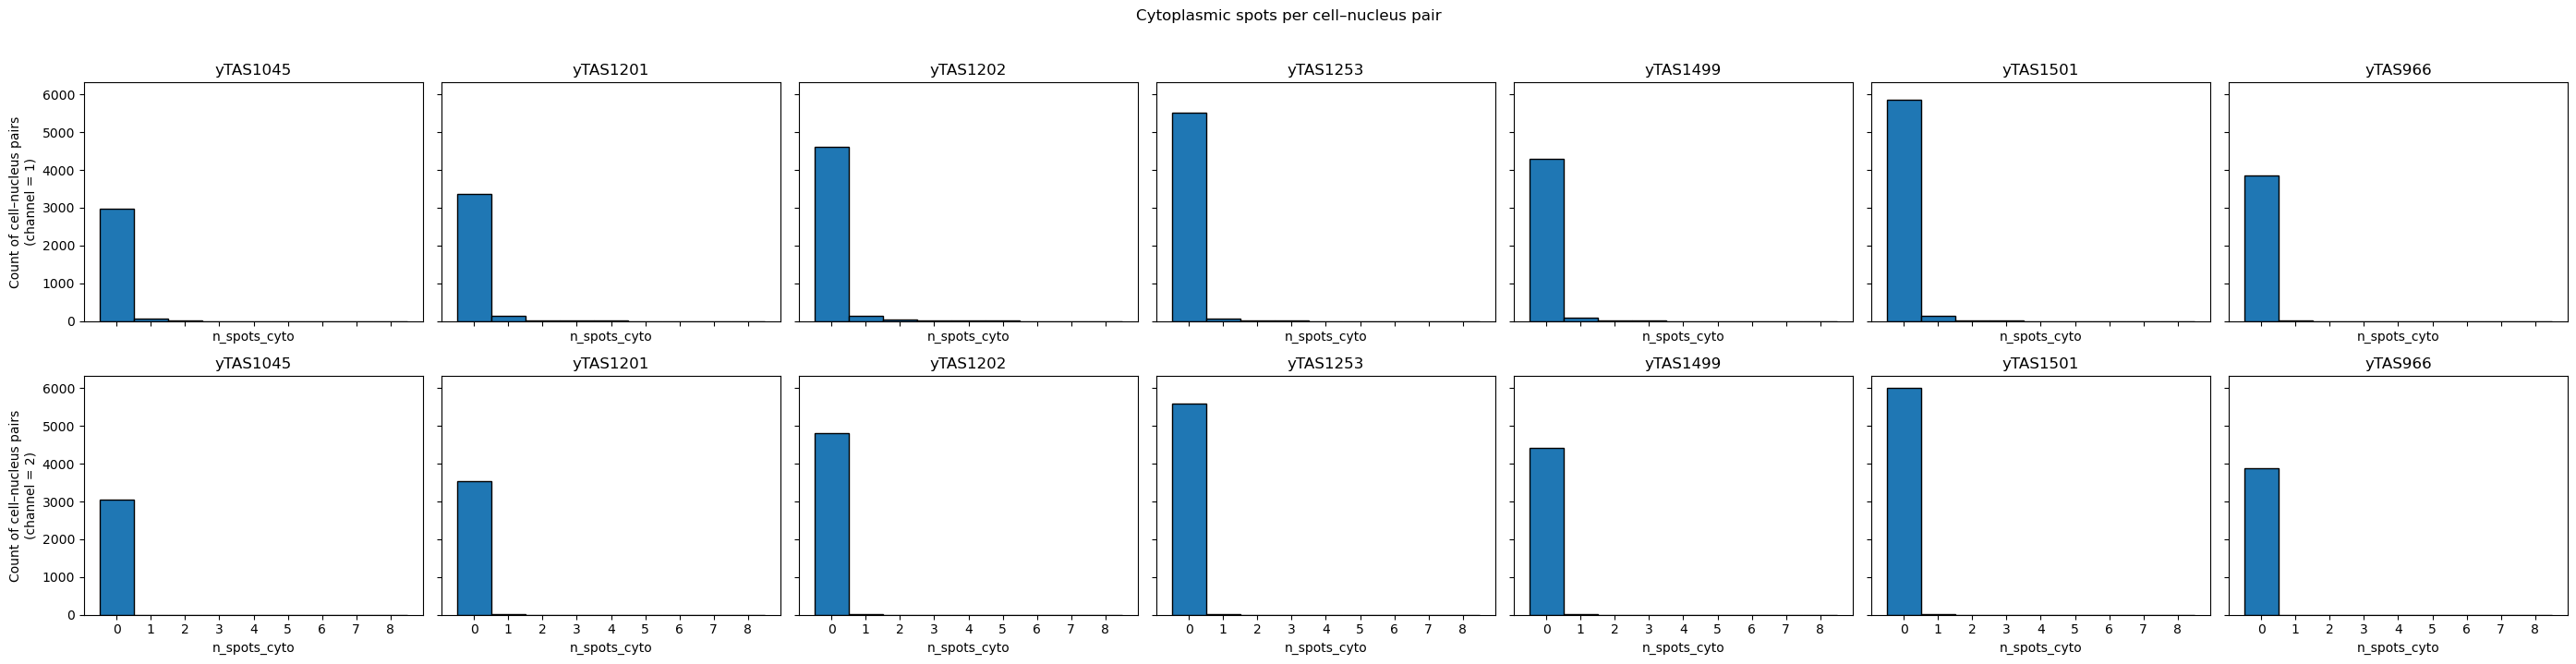

In [120]:
# 2) Plot cytoplasmic spots per cell
plot_int_hist_by_group(spot_pair_summary, "n_spots_cyto", 
                       group_col = "strain", group_row = "channel",
                       title = "Cytoplasmic spots per cell–nucleus pair")

## Spot check

Let's visually inspect cells that are scored as having fluorescent foci in the cytoplasm, to make sure we're looking at real events and not artifacts

Cells passing filter (n_spots_cyto > 0, channel 1): 130
130 panels ready for display (0 skipped).


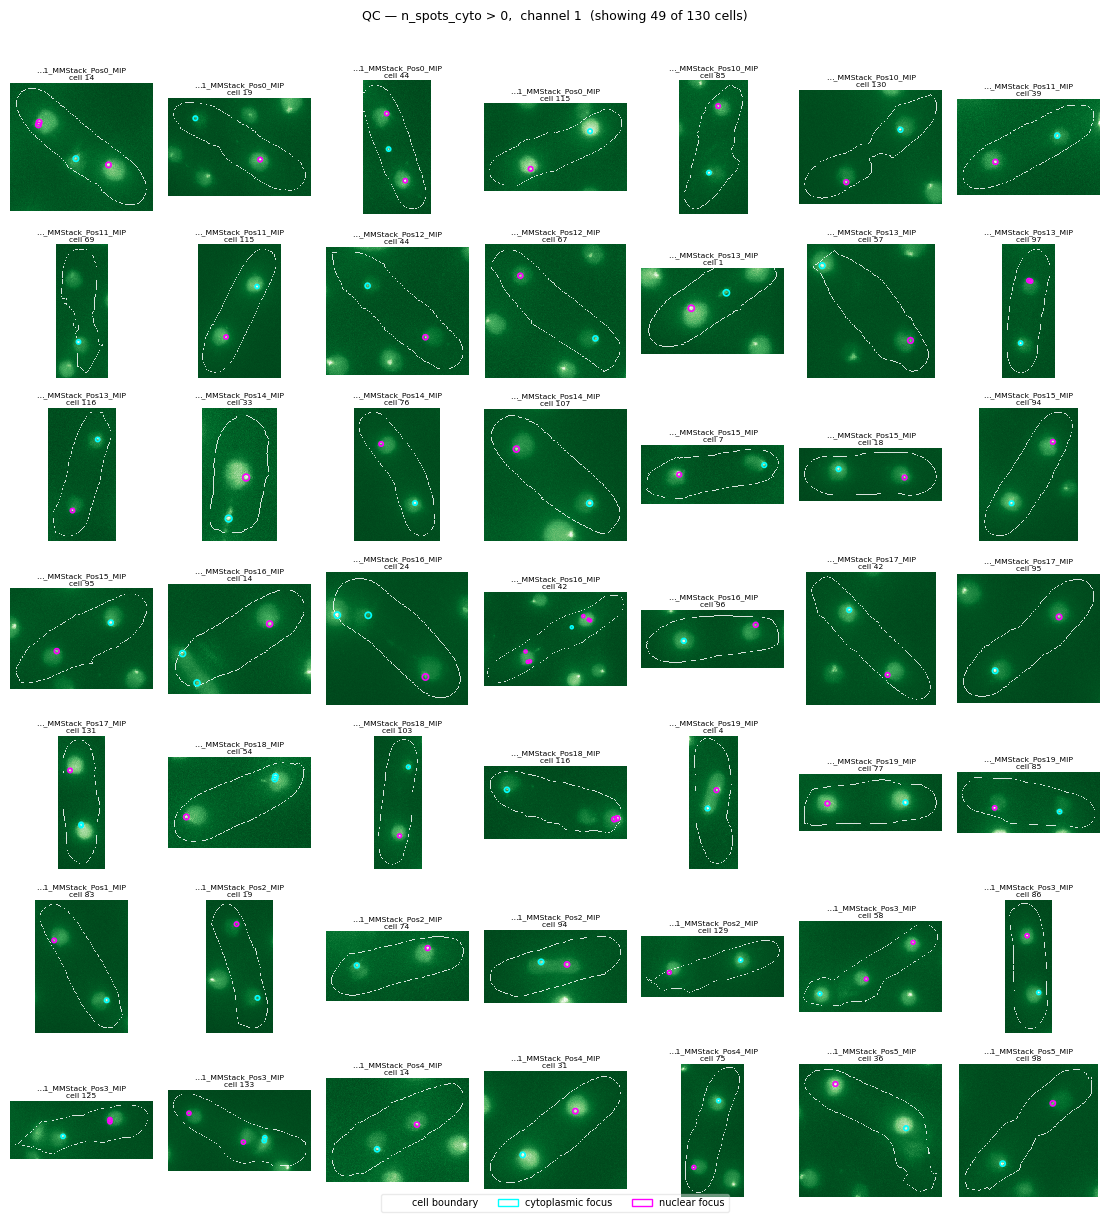

Showing first 49 of 130 cells. See PDF for up to 100.
PDF saved → /Users/nestor/Documents/NYU-ISG/python_image-analysis/plots/cytoplasmic_foci_QC.pdf  (100 cells)


In [89]:
# ============================================================
# VISUAL QC: Grid of cells with cytoplasmic foci
# ============================================================
# CONFIGURATION — adjust these to match your pipeline
# ------------------------------------------------------------

# Filtering: uses spot_pair_summary (one row per cell/channel, has counts)
# and top_spots_annot (one row per spot, has coordinates)
filter_col       = "n_spots_cyto"  # column to filter on in spot_pair_summary
filter_threshold = 0               # keep rows where filter_col > this value
FILTER_CHANNEL   = 0               # which channel to QC (integer, as in your 'channel' column)

# Channel index in your 3-channel image arrays
GFP_CHANNEL = 0   # adjust if GFP is not the first channel in your image arrays

# Column names in top_spots_annot
FOCI_X_COL   = "x"        # x coordinate of each spot
FOCI_Y_COL   = "y"        # y coordinate of each spot
FOCI_ROI_COL = "cell_ID"  # column linking each spot to a cell

# Compartment label strings (derived from nuc_ID inside lookup_foci)
FOCI_CYTO_VAL = "cytoplasm"
FOCI_NUC_VAL  = "nucleus"

# Display & output settings
PADDING       = 10    # pixels of padding around the cell bounding box crop
GRID_DISPLAY  = 7     # NxN grid shown on screen (7 = 49 panels)
MAX_PDF_CELLS = 100   # maximum panels saved to PDF
PDF_GRID_COLS = 10    # columns in the saved PDF
PDF_PATH      = os.path.join(repo_directory, "plots", "cytoplasmic_foci_QC.pdf")

# ============================================================
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
from skimage.segmentation import find_boundaries
from skimage.exposure import rescale_intensity

# ── helpers ─────────────────────────────────────────────────

def get_bounding_box(mask_2d, cell_label, padding=0):
    """Return (rmin, rmax, cmin, cmax) for one label, clamped to image edges."""
    rows, cols = np.where(mask_2d == cell_label)
    if rows.size == 0:
        return None
    h, w = mask_2d.shape
    rmin = max(0, rows.min() - padding)
    rmax = min(h, rows.max() + padding + 1)
    cmin = max(0, cols.min() - padding)
    cmax = min(w, cols.max() + padding + 1)
    return rmin, rmax, cmin, cmax


def normalize_channel(arr):
    """Stretch intensity to [0, 1] for display."""
    return rescale_intensity(arr.astype(float), out_range=(0.0, 1.0))


def find_experiment_for_base_name(all_experiments_data, base_name):
    """
    Infer which experiment a base_name belongs to by searching across all
    experiments. Since base_names are globally unique, returns the first match.
    """
    for experiment, data in all_experiments_data.items():
        if base_name in data["base_names"]["image"]:
            return experiment
    return None


def lookup_image_and_masks(all_experiments_data, experiment, base_name):
    """
    Given an experiment name and base_name, use matched_indices to find
    the corresponding image array and cell (whole-body) mask array.
    Returns (image, cell_mask) or (None, None) if not found.
    Image is returned as (H, W, C) regardless of how it was stored.
    """
    data = all_experiments_data[experiment]
    try:
        img_idx = data["base_names"]["image"].index(base_name)
    except ValueError:
        return None, None
    triple = next((t for t in data["matched_indices"] if t[0] == img_idx), None)
    if triple is None:
        return None, None
    _, _, cell_idx = triple
    image     = data["all_images"]["image"][img_idx]
    cell_mask = data["all_images"]["mask_c"][cell_idx]

    # Normalise to (H, W, C) if stored as (C, H, W) — common with ome.tif loaders
    if image.ndim == 3 and image.shape[0] < image.shape[1]:
        image = np.moveaxis(image, 0, -1)   # (C, H, W) → (H, W, C)

    return image, cell_mask


def lookup_foci(top_spots_annot, experiment, base_name, cell_id, channel):
    """
    Return spots for this cell and channel from top_spots_annot.
    Compartment is derived from nuc_ID: > 0 → nucleus, == 0 → cytoplasm.
    """
    mask = (
        (top_spots_annot["experiment"] == experiment) &
        (top_spots_annot["base_name"]  == base_name)  &
        (top_spots_annot["cell_ID"]    == cell_id)    &
        (top_spots_annot["channel"]    == channel)
    )
    df_cell = top_spots_annot.loc[mask].copy()
    df_cell["compartment"] = np.where(
        df_cell["nuc_ID"].fillna(0).astype(int) > 0,
        FOCI_NUC_VAL,
        FOCI_CYTO_VAL
    )
    return df_cell


def make_panel(ax, image, cell_mask, cell_label, foci_df, bbox, title):
    """
    Draw one QC panel on ax:
      - GFP channel in green colormap
      - Whole-cell mask boundary overlaid in white
      - Foci rings: cyan = cytoplasm, magenta = nucleus
    """
    rmin, rmax, cmin, cmax = bbox

    # GFP crop
    gfp_crop = normalize_channel(image[rmin:rmax, cmin:cmax, GFP_CHANNEL])
    ax.imshow(gfp_crop, cmap="Greens_r", vmin=0, vmax=1, interpolation="nearest")

    # Cell mask boundary overlay
    roi_binary    = (cell_mask == cell_label).astype(np.uint8)
    boundary      = find_boundaries(roi_binary, mode="outer")
    boundary_crop = boundary[rmin:rmax, cmin:cmax]
    overlay = np.zeros((*boundary_crop.shape, 4), dtype=float)
    overlay[boundary_crop] = [1, 1, 1, 0.85]
    ax.imshow(overlay, interpolation="nearest")

    # Foci rings (shift coordinates from image-space to crop-space)
    if not foci_df.empty:
        color_map = {FOCI_CYTO_VAL: "cyan", FOCI_NUC_VAL: "magenta"}
        for _, foc in foci_df.iterrows():
            fx   = foc[FOCI_X_COL] - cmin
            fy   = foc[FOCI_Y_COL] - rmin
            comp = foc.get("compartment", FOCI_NUC_VAL)
            ring = plt.Circle((fx, fy), radius=4, linewidth=1.2,
                               edgecolor=color_map.get(comp, "yellow"),
                               facecolor="none")
            ax.add_patch(ring)

    ax.set_title(title, fontsize=5.5, pad=2)
    ax.axis("off")


def build_legend(fig):
    handles = [
        mpatches.Patch(facecolor="none", edgecolor="white",   label="cell boundary"),
        mpatches.Patch(facecolor="none", edgecolor="cyan",    label="cytoplasmic focus"),
        mpatches.Patch(facecolor="none", edgecolor="magenta", label="nuclear focus"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=3,
               fontsize=7, framealpha=0.4)


# ── collect cells that pass the filter ──────────────────────

hits = (spot_pair_summary
          .loc[(spot_pair_summary[filter_col]  > filter_threshold) &
               (spot_pair_summary["channel"]   == FILTER_CHANNEL),
               ["experiment", "base_name", "cell_ID"]]
          .drop_duplicates())
print(f"Cells passing filter ({filter_col} > {filter_threshold}, "
      f"channel {FILTER_CHANNEL}): {len(hits)}")

panels = []
for _, row in hits.iterrows():
    base_name = row["base_name"]
    cell_id   = int(row["cell_ID"])

    experiment = (row["experiment"] if "experiment" in hits.columns
                  else find_experiment_for_base_name(all_experiments_data, base_name))
    if experiment is None:
        print(f"  [skip] {base_name}: not found in any experiment")
        continue

    image, cell_mask = lookup_image_and_masks(all_experiments_data, experiment, base_name)
    if image is None or cell_mask is None:
        print(f"  [skip] {experiment} / {base_name}: not found in matched data")
        continue

    bbox = get_bounding_box(cell_mask, cell_id, padding=PADDING)
    if bbox is None:
        print(f"  [skip] {experiment} / {base_name} cell_ID {cell_id}: "
              f"label absent in mask")
        continue

    foci_df    = lookup_foci(top_spots_annot, experiment, base_name,
                             cell_id, FILTER_CHANNEL)
    short_name = base_name if len(base_name) <= 20 else "…" + base_name[-18:]
    panels.append((experiment, base_name, cell_id, bbox, foci_df,
                   f"{short_name}\ncell {cell_id}"))

print(f"{len(panels)} panels ready for display "
      f"({len(hits) - len(panels)} skipped).")


# ── on-screen display: 7x7 grid ─────────────────────────────

n_display = min(len(panels), GRID_DISPLAY ** 2)
if n_display == 0:
    print("No cells to display.")
else:
    fig, axes = plt.subplots(GRID_DISPLAY, GRID_DISPLAY,
                             figsize=(GRID_DISPLAY * 1.6, GRID_DISPLAY * 1.7))
    for i, ax in enumerate(axes.flatten()):
        if i < n_display:
            exp, bn, cell_id, bbox, foci_df, title = panels[i]
            image, cell_mask = lookup_image_and_masks(all_experiments_data, exp, bn)
            make_panel(ax, image, cell_mask, cell_id, foci_df, bbox, title)
        else:
            ax.axis("off")

    build_legend(fig)
    fig.suptitle(
        f"QC — {filter_col} > {filter_threshold},  channel {FILTER_CHANNEL}  "
        f"(showing {n_display} of {len(panels)} cells)",
        fontsize=9, y=1.01
    )
    plt.tight_layout()
    plt.show()
    if len(panels) > GRID_DISPLAY ** 2:
        print(f"Showing first {GRID_DISPLAY**2} of {len(panels)} cells. "
              f"See PDF for up to {MAX_PDF_CELLS}.")


# ── PDF output: up to 100 cells ─────────────────────────────

n_pdf = min(len(panels), MAX_PDF_CELLS)
if n_pdf > 0:
    pdf_rows = int(np.ceil(n_pdf / PDF_GRID_COLS))
    with PdfPages(PDF_PATH) as pdf:
        fig, axes = plt.subplots(pdf_rows, PDF_GRID_COLS,
                                 figsize=(PDF_GRID_COLS * 1.5, pdf_rows * 1.7))
        for i, ax in enumerate(np.array(axes).flatten()):
            if i < n_pdf:
                exp, bn, cell_id, bbox, foci_df, title = panels[i]
                image, cell_mask = lookup_image_and_masks(all_experiments_data, exp, bn)
                make_panel(ax, image, cell_mask, cell_id, foci_df, bbox, title)
            else:
                ax.axis("off")

        build_legend(fig)
        fig.suptitle(
            f"QC — {filter_col} > {filter_threshold},  channel {FILTER_CHANNEL}  "
            f"({n_pdf} of {len(panels)} cells)",
            fontsize=11, y=1.01
        )
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)
    print(f"PDF saved → {PDF_PATH}  ({n_pdf} cells)")

### File saving

The following chunk exports the tables generated to the results folder 

In [121]:
# FILE SAVING #

# Save the tables generated to the results folder in the analysis repository

# Files for each experiment will be saved in their own folder as .csv files
# This approach makes it easy to import them into other notebooks and combine them again if needed

# Files will be saved in the "results" folder of the analysis repository
results_dir = os.path.join(repo_directory, "results")

# Get today's date string to use as a suffix if older versions of the file are present
import datetime
date_suffix = datetime.datetime.now().strftime("%m%d%Y")

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Define the folder for the current experiment inside the results folder
    # and create it if not already present
    experiment_folder = os.path.join(results_dir, experiment)
    os.makedirs(experiment_folder, exist_ok=True)
    
    # Filter the Data Frame for the current experiment 
    nuclei_counts_e = nuclei_counts[nuclei_counts['experiment'] == experiment]
    all_spots_annot_e = all_spots_annot[all_spots_annot['experiment'] == experiment]
    spot_pair_summary_e = spot_pair_summary[spot_pair_summary['experiment'] == experiment]
    
    # Define the default file path for the CSV file
    nuc_counts_file = os.path.join(experiment_folder, "nuclei_counts.csv")
    spots_annot_file = os.path.join(experiment_folder, "spots_annotated.csv")
    spots_counts_file = os.path.join(experiment_folder, "spots_counts.csv")
    
    # If the raw (no BS) file already exists, add the date suffix to create a new filename
    if os.path.exists(nuc_counts_file):
        nuc_counts_file = os.path.join(experiment_folder, f"nuclei_counts_{date_suffix}.csv")
        spots_annot_file = os.path.join(experiment_folder, f"spots_annotated_{date_suffix}.csv")
        spots_counts_file = os.path.join(experiment_folder, f"spots_counts_{date_suffix}.csv")
    
    # Save the data frame to its CSV file
    nuclei_counts_e.to_csv(nuc_counts_file, index=False)
    all_spots_annot_e.to_csv(spots_annot_file, index=False)
    spot_pair_summary_e.to_csv(spots_counts_file, index=False)